# Transcriptomic Prediction of Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer
### A Spearman-Filtered, Bayesian-Optimised Machine Learning Framework with SHAP Explainability

---

## Clinical Motivation

Neoadjuvant chemotherapy (NAC) is standard-of-care for locally advanced and high-risk early breast cancer. However, only **15–53%** of patients achieve pathological complete response (pCR), defined as the absence of residual invasive disease in the breast and axillary nodes at surgery (Cortazar et al., 2014, *Lancet*). The remaining patients are exposed to cytotoxic side effects **without therapeutic benefit**, and may experience disease progression that adversely affects surgical outcomes (Asaoka et al., 2019, *Eur J Surg Oncol*).

**pCR is a validated surrogate for long-term survival**: a pooled analysis of 5,161 patients demonstrated that residual cancer burden after NAC is significantly associated with event-free survival across all breast cancer subtypes (Yau et al., 2022, *Lancet Oncology*).

**The clinical question this pipeline addresses:**
> *Given a patient's pre-treatment tumour transcriptomic profile, can we predict whether they will achieve pCR — and therefore identify patients most likely to benefit from NAC?*

## Dataset

- **GSE163882:** 222 multi-institutional breast cancer biopsies (RNA-seq, Illumina NextSeq 500)
- Published by Park et al. (2020, *Nature Communications*): "Chemotherapy induces dynamic immune responses in breast cancers that impact treatment outcome"
- Pre-treatment biopsies with known pCR/RD outcomes after anthracycline/taxane-based NAC

## Methodological Framework

This pipeline replicates and extends the approach of **Chen et al. (2022, *Frontiers in Immunology*)**, who used Spearman rank correlation for feature selection and model stacking with Bayesian optimisation on this dataset, achieving AUROC = 0.745 on an independent RNA-seq test set.

**Key methodological decisions** (each backed by peer-reviewed evidence):

| Decision | Rationale | Reference |
|----------|-----------|-----------|
| Spearman correlation feature selection | Non-parametric, detects monotonic associations without distributional assumptions | Chen et al. (2022); Hauke & Kossowski (2011) |
| Cost-sensitive learning over SMOTE | SMOTE is harmful in high-dimensional settings (p >> n) | Blagus & Lusa (2013, *BMC Bioinformatics*) |
| Bayesian hyperparameter optimisation | Efficient search over continuous parameter spaces | Snoek et al. (2012, *NeurIPS*) |
| SHAP explainability | Model-agnostic, theoretically grounded feature attribution | Lundberg & Lee (2017, *NeurIPS*) |
| Stratified train/test split with leakage prevention | Feature selection on training set only | Hastie et al. (2009, *Elements of Statistical Learning*) |


## Section 1: Environment Setup


In [1]:
# Install required packages (run once)
# Uncomment if running for the first time
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap umap-learn imbalanced-learn GEOparse requests tqdm


In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import re
import json
import requests
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve,
                              average_precision_score, matthews_corrcoef)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Explainability ───────────────────────────────────────────────────────────
import shap
shap.initjs()

# ── Dimensionality Reduction ─────────────────────────────────────────────────
import umap

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


# ── Output directory ─────────────────────────────────────────────────────────
RESULTS_DIR = 'results_spearman'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")

from scipy.stats import spearmanr


All libraries loaded successfully.
Pandas version: 3.0.3
Scikit-learn version: 1.8.0


## Section 2: Data Loading and Inspection

Load the TPM expression matrix and series matrix metadata file. The GSE163882 dataset (Hatzis et al.) comprises RNA-seq transcriptomes from 222 breast cancer biopsies collected across multiple institutions prior to neoadjuvant chemotherapy.

**Data source:** GEO Accession [GSE163882](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE163882)


### Data Provenance & Normalisation

**RNA-seq quantification**: Transcripts per million (TPM) values are used as the expression measure. TPM normalises for both sequencing depth and gene length, making expression levels comparable across samples and genes (Wagner et al., 2012, *Theory in Biosciences*). The log₂(TPM+1) transformation is applied downstream to stabilise variance and approximate normality.

**Platform advantage**: RNA-seq was chosen over microarray because it offers wider dynamic range, higher reproducibility through digital quantification (rather than analogue hybridisation intensity), and lower sample requirements — critical considerations for clinical deployment (Wang et al., 2009, *Nature Reviews Genetics*). Chen et al. (2022) specifically noted that microarray-based models suffer from batch effects and data leakage during normalisation.


In [3]:
# ── File paths (adjust if files are in a subfolder) ─────────────────────────
TPM_FILE    = "GSE163882_all.data.tpms_222Samples.csv"
MATRIX_FILE = "GSE163882_series_matrix.txt"

# ── Load TPM expression data ─────────────────────────────────────────────────
print("Loading TPM expression matrix...")
tpm_raw = pd.read_csv(TPM_FILE, index_col=0)

# Drop non-sample columns (e.g. 'annotation')
non_sample_cols = [c for c in tpm_raw.columns if not c.startswith('BA')]
if non_sample_cols:
    print(f"Dropping non-sample columns: {non_sample_cols}")
    tpm_raw = tpm_raw.drop(columns=non_sample_cols)

print(f"TPM matrix shape (genes x samples): {tpm_raw.shape}")
print(f"First 5 gene names: {tpm_raw.index[:5].tolist()}")
print(f"First 3 sample IDs: {tpm_raw.columns[:3].tolist()}")
tpm_raw.head(3)


Loading TPM expression matrix...
Dropping non-sample columns: ['annotation']
TPM matrix shape (genes x samples): (60279, 222)
First 5 gene names: ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']
First 3 sample IDs: ['BA00129', 'BA00130', 'BA00132']


,BA00129,BA00130,BA00132,BA00133,BA00135,BA00136,BA00137,BA00138,BA00139,BA00140,BA00141,BA00142,BA00143,BA00145,BA00146,BA00147,BA00148,BA00149,BA00150,BA00151,BA00152,BA00161,BA00162,BA00163,BA00165,...,BA00638,BA00639,BA00640,BA00641,BA00643,BA00644,BA00645,BA00646,BA00647,BA00648,BA00649,BA00651,BA00653,BA00654,BA00655,BA00027,BA00063,BA00101,BA00134,BA00154,BA00164,BA00166,BA00448,BA00586,BA00636
ENSG00000000003,6.2400,12.1900,9.1900,1.2300,5.0000,4.9900,3.2900,5.2700,11.1600,7.2500,7.3300,1.6900,10.4300,26.8600,21.0300,1.5500,4.5800,8.4600,5.6400,2.1800,8.8700,4.5600,3.5700,5.4100,1.1400,...,6.6600,9.5300,2.7600,9.0300,9.7700,12.6900,5.1000,9.9200,10.8600,4.1200,12.9700,6.4500,13.5500,6.0300,7.9400,1.0200,4.4900,8.7800,8.0100,1.5400,7.8800,8.6800,7.9800,8.6900,0.0500
ENSG00000000005,0.0000,0.0000,0.4600,0.0000,0.0000,0.2700,0.0000,0.3900,0.0000,0.0300,1.2800,0.0000,0.2000,0.2000,0.0300,0.0000,0.0000,0.5000,0.2600,0.0000,0.0000,0.0100,0.0000,0.0000,0.0000,...,0.7200,0.1800,0.1100,0.0400,0.2600,0.0300,0.0400,0.4300,0.2300,0.2600,0.6700,0.1600,1.8300,2.9500,0.2000,0.0000,0.0000,0.2200,0.0000,2.7400,0.0000,0.0000,1.2800,0.3400,0.0000
ENSG00000000419,28.4100,16.7500,60.7400,0.0000,42.8800,16.3900,4.9000,14.0400,5.0300,55.1600,42.1500,1.4400,111.5200,36.0300,79.0900,3.2700,46.2400,9.7200,25.8200,6.3800,59.3700,24.6300,8.7700,15.8000,1.9000,...,41.1000,46.1900,50.0700,66.1500,48.1000,90.3600,22.1700,35.9400,50.2000,38.9400,54.2100,44.0400,101.5500,60.7100,33.3000,26.5500,30.2000,55.4900,35.2100,2.1400,31.0600,21.8800,64.8000,26.2000,1.4700


In [4]:
# ── Transpose so samples are rows and genes are columns ─────────────────────
tpm = tpm_raw.T
print(f"Transposed shape (samples x genes): {tpm.shape}")
tpm.head(3)


Transposed shape (samples x genes): (222, 60279)


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,ENSG00000001561,ENSG00000001617,ENSG00000001626,ENSG00000001629,ENSG00000001630,ENSG00000001631,ENSG00000002016,ENSG00000002079,ENSG00000002330,ENSG00000002549,ENSG00000002586,ENSG00000002587,...,ENSG00000280430,ENSG00000280431,ENSG00000280432,ENSG00000280433,ENSG00000280434,ENSG00000280435,ENSG00000280436,ENSG00000280437,ENSG00000280438,ENSG00000280439,ENSG00000280440,ENSG00000280441,ENSG00000280442,ENSG00000280443,ENSG00000280444,ENSG00000280445,ENSG00000280446,ENSG00000280447,ENSG00000280448,ENSG00000280449,ENSG00000280450,ENSG00000280451,ENSG00000280452,ENSG00000280453,ENSG00000280454
BA00129,6.2400,0.0000,28.4100,1.7800,2.7300,0.0000,4.2500,5.8100,14.3900,7.6500,3.5000,2.5600,1.1100,0.2500,1.8300,0.0100,11.6400,33.3600,0.1400,13.7100,0.1500,10.3400,117.4600,40.6900,0.0600,...,0.0000,0.0000,0.0000,0.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.9800,0.0000,0.0000,0.1100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BA00130,12.1900,0.0000,16.7500,2.9000,1.1100,2.9400,8.5500,5.7200,38.3000,29.2400,3.4700,0.3200,0.8400,0.3700,6.0500,0.0000,9.6600,22.4600,0.5100,1.0000,0.0200,5.1400,41.2000,108.7500,0.1100,...,0.0000,0.0000,0.0000,0.0300,0.1600,0.0000,0.0000,0.0800,0.0000,0.0000,0.0000,3.5100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BA00132,9.1900,0.4600,60.7400,1.3200,3.7200,6.5800,32.2900,6.9500,19.3200,29.5300,15.1700,5.3500,2.6800,1.6000,2.6900,0.0200,35.3900,34.3600,0.0000,15.3600,0.0000,13.8100,101.2800,65.2900,0.2800,...,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Section 3: Metadata Extraction and Target Variable

Parse the GEO series matrix file to extract clinical annotations including pCR/RD treatment response labels. The series matrix format stores sample characteristics as key-value pairs that require structured parsing. pCR (pathological Complete Response) indicates complete tumour eradication after chemotherapy, while RD (Residual Disease) indicates persistent tumour tissue.


In [5]:
# ── Parse series matrix file ─────────────────────────────────────────────────
print("Parsing series matrix file...")

sample_ids    = []
char_data     = {}
sample_titles = []

with open(MATRIX_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        
        # Sample accession IDs
        if line.startswith('!Sample_geo_accession'):
            sample_ids = line.split('\t')[1:]
            sample_ids = [s.strip('"') for s in sample_ids]
        
        # Sample titles (contain BA codes for crosswalk)
        if line.startswith('!Sample_title'):
            sample_titles = line.split('\t')[1:]
            sample_titles = [s.strip('"') for s in sample_titles]
        
        # All characteristics lines
        if line.startswith('!Sample_characteristics_ch1'):
            values = line.split('\t')[1:]
            values = [v.strip('"') for v in values]
            
            # Determine field name from first non-empty value
            key = values[0].split(':')[0].strip() if ':' in values[0] else f"char_{len(char_data)}"
            parsed = []
            for v in values:
                if ':' in v:
                    parsed.append(v.split(':', 1)[1].strip())
                else:
                    parsed.append(v.strip())
            char_data[key] = parsed

print(f"Found {len(sample_ids)} samples")
print(f"Characteristics fields found: {list(char_data.keys())}")
print(f"Sample titles (first 3): {sample_titles[:3]}")


Parsing series matrix file...
Found 222 samples
Characteristics fields found: ['response to nac', 'age', 'estrogen receptor status', 'progesterone receptor status', 'her2 receptor status', 'tumor grage', 'breast cancer stage', 'tissue']
Sample titles (first 3): ['BA00111: WT169901238(A1)', 'BA00568: CS16-10701', 'BA00116: WT169912674(A1)']


In [6]:
# ── Build metadata dataframe ─────────────────────────────────────────────────
meta = pd.DataFrame(char_data, index=sample_ids)
print(f"Metadata shape: {meta.shape}")
print("\nAll metadata columns:")
for col in meta.columns:
    print(f"  '{col}': {meta[col].unique()[:5]}")
meta.head()


Metadata shape: (222, 8)

All metadata columns:
  'response to nac': <StringArray>
['pCR', 'RD']
Length: 2, dtype: str
  'age': <StringArray>
['65', '51', '59', '56', '45']
Length: 5, dtype: str
  'estrogen receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'progesterone receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'her2 receptor status': <StringArray>
['N', 'P']
Length: 2, dtype: str
  'tumor grage': <StringArray>
['3', '2', '1', '0']
Length: 4, dtype: str
  'breast cancer stage': <StringArray>
['NA', '1', '2', '3', '4']
Length: 5, dtype: str
  'tissue': <StringArray>
['breast cancer']
Length: 1, dtype: str


,response to nac,age,estrogen receptor status,progesterone receptor status,her2 receptor status,tumor grage,breast cancer stage,tissue
GSM4989073,pCR,65,N,N,N,3,NA,breast cancer
GSM4989074,pCR,51,N,N,P,3,NA,breast cancer
GSM4989075,pCR,59,N,N,P,2,NA,breast cancer
GSM4989076,pCR,56,N,N,P,3,NA,breast cancer
GSM4989077,pCR,45,P,P,P,3,NA,breast cancer


In [7]:
# ── Extract pCR/RD target label ──────────────────────────────────────────────
# Identify which column contains pCR/RD information
# Look for the column containing 'pCR' or 'RD' or 'response'
target_col = None
for col in meta.columns:
    unique_vals = meta[col].str.lower().unique()
    if any('pcr' in str(v) or 'residual' in str(v) or 
           ' rd' in str(v) or 'response' in str(v) 
           for v in unique_vals):
        target_col = col
        print(f"Target column found: '{col}'")
        print(f"Unique values: {meta[col].unique()}")
        break

if target_col is None:
    print("\nCould not auto-detect. Printing all unique values per column:")
    for col in meta.columns:
        print(f"  {col}: {meta[col].unique()}")


Target column found: 'response to nac'
Unique values: <StringArray>
['pCR', 'RD']
Length: 2, dtype: str


In [ ]:
# ── Standardise label to pCR / RD ────────────────────────────────────────────
# Common values seen: 'pCR', 'PCR', 'RD', 'residual disease'

meta['label'] = meta[target_col].str.strip()

# Normalise to consistent labels
meta['label'] = meta['label'].replace({
    'PCR': 'pCR', 'pcr': 'pCR',
    'Residual Disease': 'RD', 'residual disease': 'RD',
    'RD ': 'RD', 'pCR ': 'pCR'
})

print("Label distribution:")
print(meta['label'].value_counts())
print(f"\nTotal samples with labels: {meta['label'].notna().sum()}")


Label distribution:
label
RD     142
pCR     80
Name: count, dtype: int64

Total samples with labels: 222


In [9]:
# ── Extract additional clinical variables if available ───────────────────────
# Subtype (TNBC vs non-TNBC)
for col in meta.columns:
    if any('tnbc' in str(v).lower() or 'triple' in str(v).lower() 
           or 'subtype' in str(v).lower() or 'her2' in str(v).lower()
           for v in meta[col].unique()):
        meta['subtype'] = meta[col].str.strip()
        print(f"Subtype column: '{col}'")
        print(meta['subtype'].value_counts())
        break

meta.head()


,response to nac,age,estrogen receptor status,progesterone receptor status,her2 receptor status,tumor grage,breast cancer stage,tissue,label
GSM4989073,pCR,65,N,N,N,3,NA,breast cancer,pCR
GSM4989074,pCR,51,N,N,P,3,NA,breast cancer,pCR
GSM4989075,pCR,59,N,N,P,2,NA,breast cancer,pCR
GSM4989076,pCR,56,N,N,P,3,NA,breast cancer,pCR
GSM4989077,pCR,45,P,P,P,3,NA,breast cancer,pCR


## Section 4: Data Merging and Quality Check

Merge the TPM expression matrix with clinical metadata using sample IDs as the join key. This step performs the critical BA-code to GSM-ID crosswalk between the expression matrix (which uses internal BA identifiers) and the metadata (which uses GEO GSM accession numbers). Data quality checks include missing value detection and duplicate sample identification.


In [ ]:
# ── Align sample IDs  ──────────────────────────────────
# TPM matrix uses BA codes (e.g., BA00129) while metadata uses GSM accessions
# (e.g., GSM4989073). The BA code is embedded in the Sample_title field.

print(f"TPM sample IDs (first 3):  {tpm.index[:3].tolist()}")
print(f"Meta sample IDs (first 3): {meta.index[:3].tolist()}")

# Build BA-code → GSM mapping from sample titles
ba_to_gsm = {}
for gsm, title in zip(sample_ids, sample_titles):
    ba_code = title.split(':')[0].strip()
    ba_to_gsm[ba_code] = gsm

print(f"\nBA-to-GSM mappings built: {len(ba_to_gsm)}")
print(f"Example: {list(ba_to_gsm.items())[:3]}")

# Map TPM BA codes to GSM IDs
tpm.index = tpm.index.map(lambda x: ba_to_gsm.get(x, x))

# Find common samples
common_samples = tpm.index.intersection(meta.index)
unmapped = [x for x in tpm.index if x.startswith('BA')]  # still BA = unmapped

print(f"\nCommon samples after crosswalk: {len(common_samples)}")
print(f"Unmapped TPM samples: {len(unmapped)}")
print(f"Only in meta: {len(meta.index.difference(tpm.index))}")


TPM sample IDs (first 3):  ['BA00129', 'BA00130', 'BA00132']
Meta sample IDs (first 3): ['GSM4989073', 'GSM4989074', 'GSM4989075']

BA-to-GSM mappings built: 222
Example: [('BA00111', 'GSM4989073'), ('BA00568', 'GSM4989074'), ('BA00116', 'GSM4989075')]

Common samples after crosswalk: 222
Unmapped TPM samples: 0
Only in meta: 0


In [11]:
# ── Merge on common samples ──────────────────────────────────────────────────
tpm_aligned  = tpm.loc[common_samples]
meta_aligned = meta.loc[common_samples]

# Combine into one dataframe
data = tpm_aligned.copy()
data['label']   = meta_aligned['label']
if 'subtype' in meta_aligned.columns:
    data['subtype'] = meta_aligned['subtype']

# Remove samples with missing labels
data = data.dropna(subset=['label'])
print(f"Final dataset shape: {data.shape}")
print(f"\nLabel counts:")
print(data['label'].value_counts())

# Encode labels: pCR = 1, RD = 0
le = LabelEncoder()
data['label_enc'] = le.fit_transform(data['label'])
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


# ── Parse receptor status and derive TNBC subtype ───────────────────────
if 'Sample_characteristics_ch1_3' in meta.columns:
    data['ER'] = meta_aligned['Sample_characteristics_ch1_3'].str.extract(r': (\w)')[0].values
    data['PR'] = meta_aligned['Sample_characteristics_ch1_4'].str.extract(r': (\w)')[0].values
    data['HER2'] = meta_aligned['Sample_characteristics_ch1_5'].str.extract(r': (\w)')[0].values
    
    # TNBC = ER-negative AND PR-negative AND HER2-negative
    data['subtype'] = 'non-TNBC'
    tnbc_mask = (data['ER'] == 'N') & (data['PR'] == 'N') & (data['HER2'] == 'N')
    data.loc[tnbc_mask, 'subtype'] = 'TNBC'
    
    print(f"\nReceptor status parsed:")
    print(f"  ER+: {(data['ER']=='P').sum()}, ER-: {(data['ER']=='N').sum()}")
    print(f"  PR+: {(data['PR']=='P').sum()}, PR-: {(data['PR']=='N').sum()}")
    print(f"  HER2+: {(data['HER2']=='P').sum()}, HER2-: {(data['HER2']=='N').sum()}")
    print(f"  TNBC: {tnbc_mask.sum()} ({tnbc_mask.mean()*100:.1f}%)")
    print(f"  non-TNBC: {(~tnbc_mask).sum()} ({(~tnbc_mask).mean()*100:.1f}%)")
else:
    print("\nNo receptor status columns found in metadata.")


Final dataset shape: (222, 60280)

Label counts:
label
RD     142
pCR     80
Name: count, dtype: int64

Encoding: {'RD': np.int64(0), 'pCR': np.int64(1)}

No receptor status columns found in metadata.


In [12]:
# ── Basic data quality check ─────────────────────────────────────────────────
print("=== Data Quality Report ===")
print(f"Total samples:       {data.shape[0]}")
gene_cols = [c for c in data.columns if c not in ['label', 'label_enc', 'subtype']]
print(f"Total gene features: {len(gene_cols)}")
print(f"Missing values:      {data.isnull().sum().sum()}")
print(f"Duplicate samples:   {data.index.duplicated().sum()}")

if data.shape[0] > 0:
    tpm_stats = data[gene_cols].values.flatten()
    print(f"\nTPM value statistics:")
    print(f"  Min:    {tpm_stats.min():.3f}")
    print(f"  Mean:   {tpm_stats.mean():.3f}")
    print(f"  Median: {np.median(tpm_stats):.3f}")
    print(f"  Max:    {tpm_stats.max():.3f}")
else:
    print("\n⚠️ WARNING: No samples in merged dataset. Check crosswalk.")


=== Data Quality Report ===
Total samples:       222
Total gene features: 60279
Missing values:      0
Duplicate samples:   0

TPM value statistics:
  Min:    0.000
  Mean:   16.590
  Median: 0.000
  Max:    326199.540


## Section 5: Exploratory Data Analysis (EDA)

Comprehensive visualisation of data structure, class distribution, expression patterns, and sample-level relationships. EDA is essential before model building to identify potential confounders, batch effects, and data quality issues.

**Techniques applied:**
- Class distribution analysis to quantify label imbalance
- TPM distribution before/after log2 transformation
- PCA for linear dimensionality reduction and variance decomposition.
- UMAP for non-linear manifold learning (McInnes et al., 2018, *JMLR*)
- Heatmap of top variable genes to assess expression heterogeneity


### Exploratory Data Analysis Rationale

EDA serves two purposes in a clinical prediction pipeline:

1. **Verify data integrity:** confirm expected class distributions, detect batch effects, and identify outlier samples that may represent technical artefacts rather than biological variation.

2. **Characterise the learning problem:** pCR prediction from transcriptomic data is inherently a "needle in a haystack" problem: the signal is distributed across many weakly informative genes embedded in a high-dimensional feature space. PCA and UMAP visualisations reveal whether the pCR/RD distinction manifests as a clear separation (easily learnable) or an overlapping distribution (requiring sophisticated models).

**Expected biological pattern**: Tumours achieving pCR tend to have higher immune infiltration signatures (Denkert et al., 2010, *JCO*), which should manifest as partial separation along immune-related principal components.


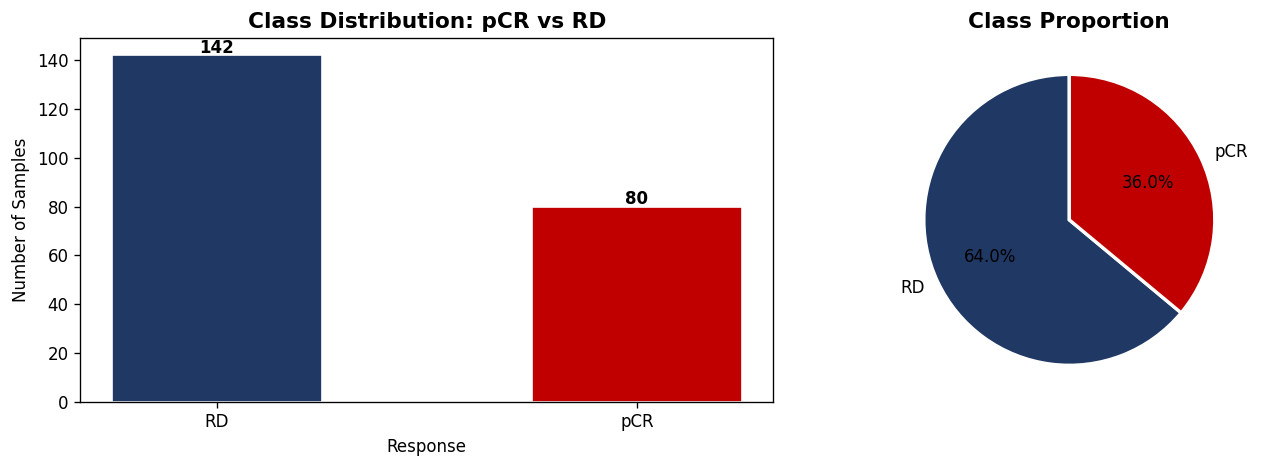

Class imbalance ratio: 1.77:1


In [13]:
# ── 5.1 Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = data['label'].value_counts()
colors = ['#1F3864', '#C00000']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution: pCR vs RD', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Response')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {counts.max()/counts.min():.2f}:1")


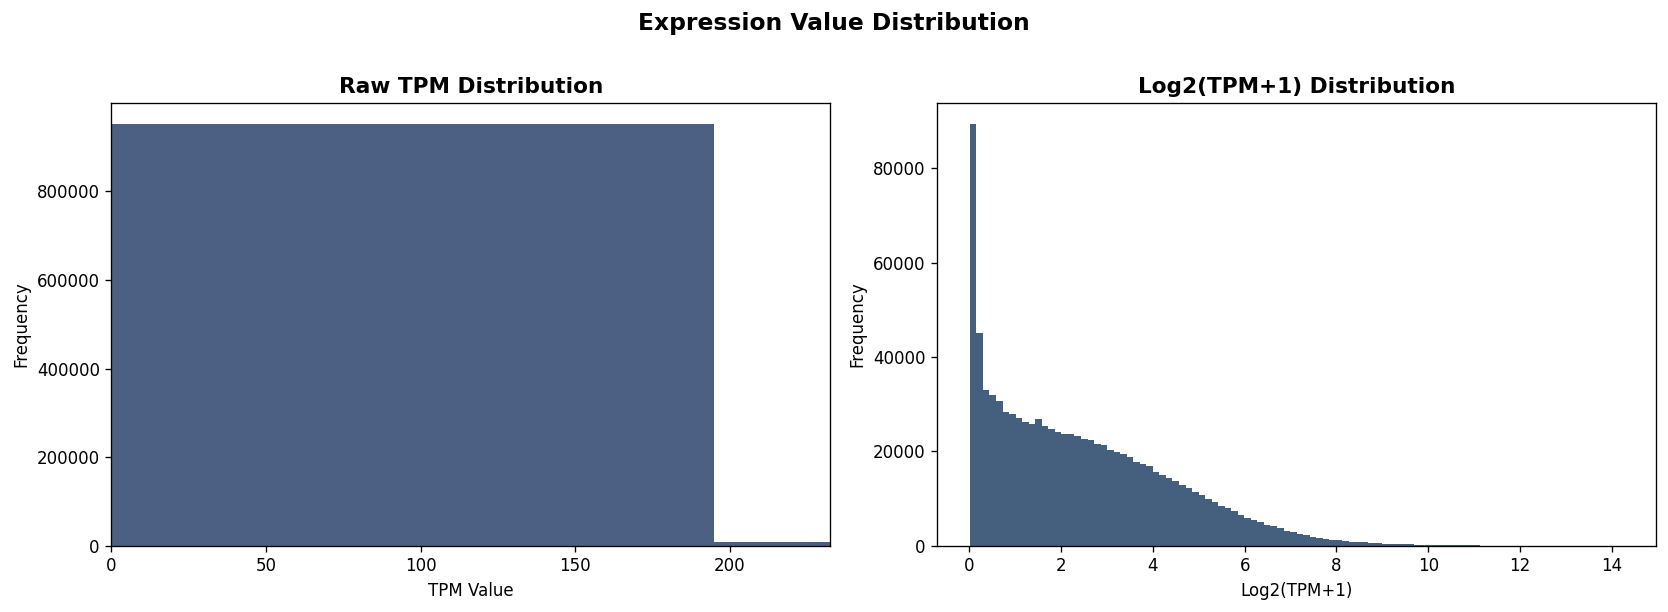

In [14]:
# ── 5.2 TPM distribution before and after log transformation ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select a subset of genes for speed
sample_genes = gene_cols[:5000]
tpm_vals     = data[sample_genes].values.flatten()
tpm_vals     = tpm_vals[tpm_vals > 0]  # remove zeros for log

axes[0].hist(tpm_vals, bins=100, color='#1F3864', alpha=0.8, edgecolor='none')
axes[0].set_title('Raw TPM Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('TPM Value')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([0, np.percentile(tpm_vals, 99)])

log_vals = np.log2(tpm_vals + 1)
axes[1].hist(log_vals, bins=100, color='#17375E', alpha=0.8, edgecolor='none')
axes[1].set_title('Log2(TPM+1) Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log2(TPM+1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Expression Value Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tpm_distribution.png'), bbox_inches='tight')
plt.show()


Running PCA...


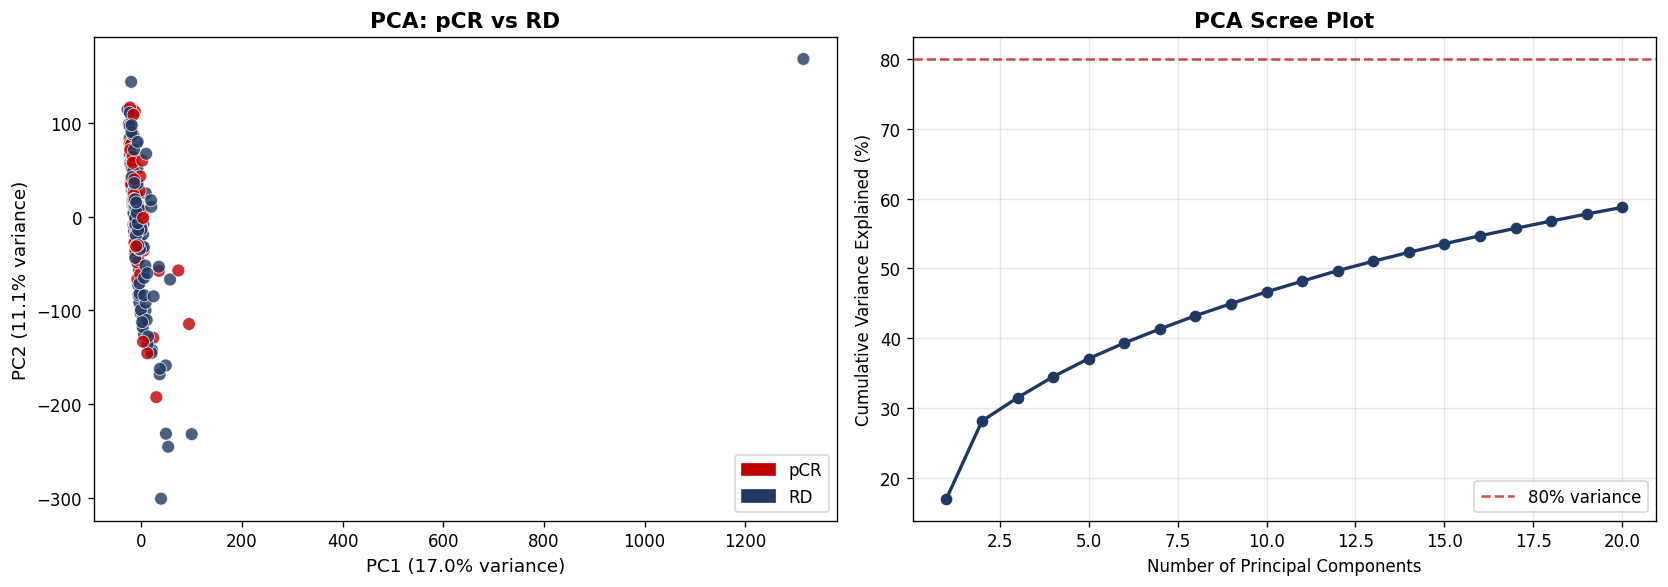

PCs needed for 80% variance: 1


In [ ]:
# ── 5.3 PCA Visualisation ────────────────────────────────────────────────────
print("Running PCA...")
X_raw = data[gene_cols].values
y     = data['label_enc'].values

# Log transform first
X_log = np.log2(X_raw + 1)

# Standardise
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# PCA
pca     = PCA(n_components=50, random_state=42)
X_pca   = pca.fit_transform(X_scaled)

# Variance explained
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
colors_map = {0: '#1F3864', 1: '#C00000'}
color_list = [colors_map[l] for l in y]
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=color_list, alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)', fontsize=11)
axes[0].set_title('PCA: pCR vs RD', fontsize=13, fontweight='bold')
patches = [mpatches.Patch(color='#C00000', label='pCR'),
           mpatches.Patch(color='#1F3864', label='RD')]
axes[0].legend(handles=patches)

# Scree plot
axes[1].plot(range(1, 21), cum_var[:20]*100, 'o-', color='#1F3864', linewidth=2)
axes[1].axhline(y=80, color='#C00000', linestyle='--', alpha=0.7, label='80% variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('PCA Scree Plot', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pca_analysis.png'), bbox_inches='tight')
plt.show()



Running UMAP (this may take 1-2 minutes)...


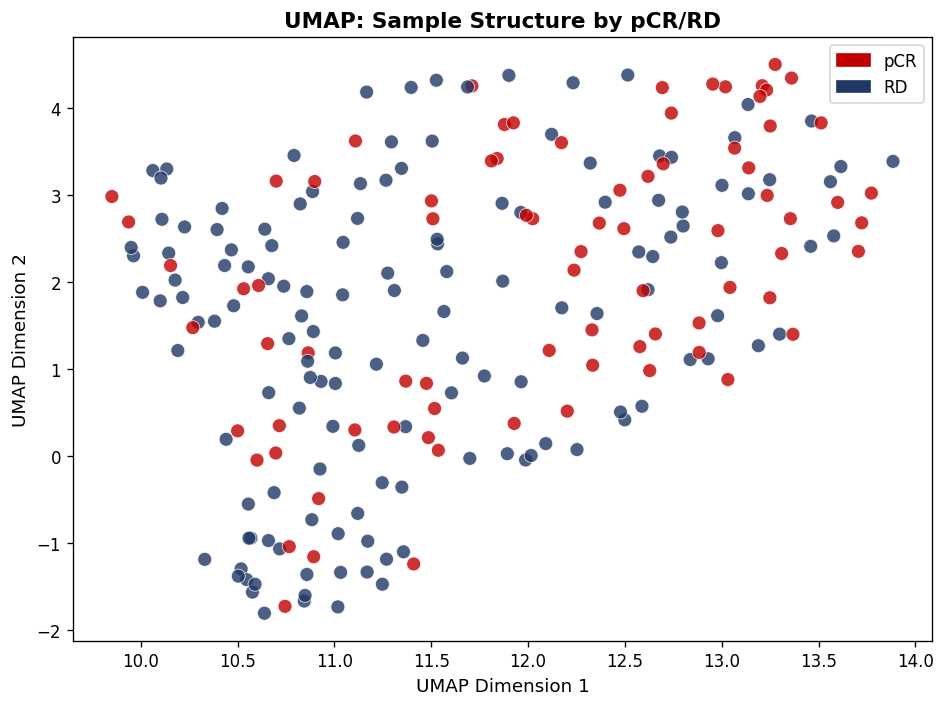

In [ ]:
# ── 5.4 UMAP Visualisation ───────────────────────────────────────────────────
print("Running UMAP...")
reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap   = reducer.fit_transform(X_scaled)

fig, ax  = plt.subplots(figsize=(8, 6))
scatter  = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=color_list, alpha=0.8, s=70,
                      edgecolors='white', linewidth=0.5)
ax.set_xlabel('UMAP Dimension 1', fontsize=11)
ax.set_ylabel('UMAP Dimension 2', fontsize=11)
ax.set_title('UMAP: Sample Structure by pCR/RD', fontsize=13, fontweight='bold')
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'umap_analysis.png'), bbox_inches='tight')
plt.show()


Generating expression heatmap for top variable genes...


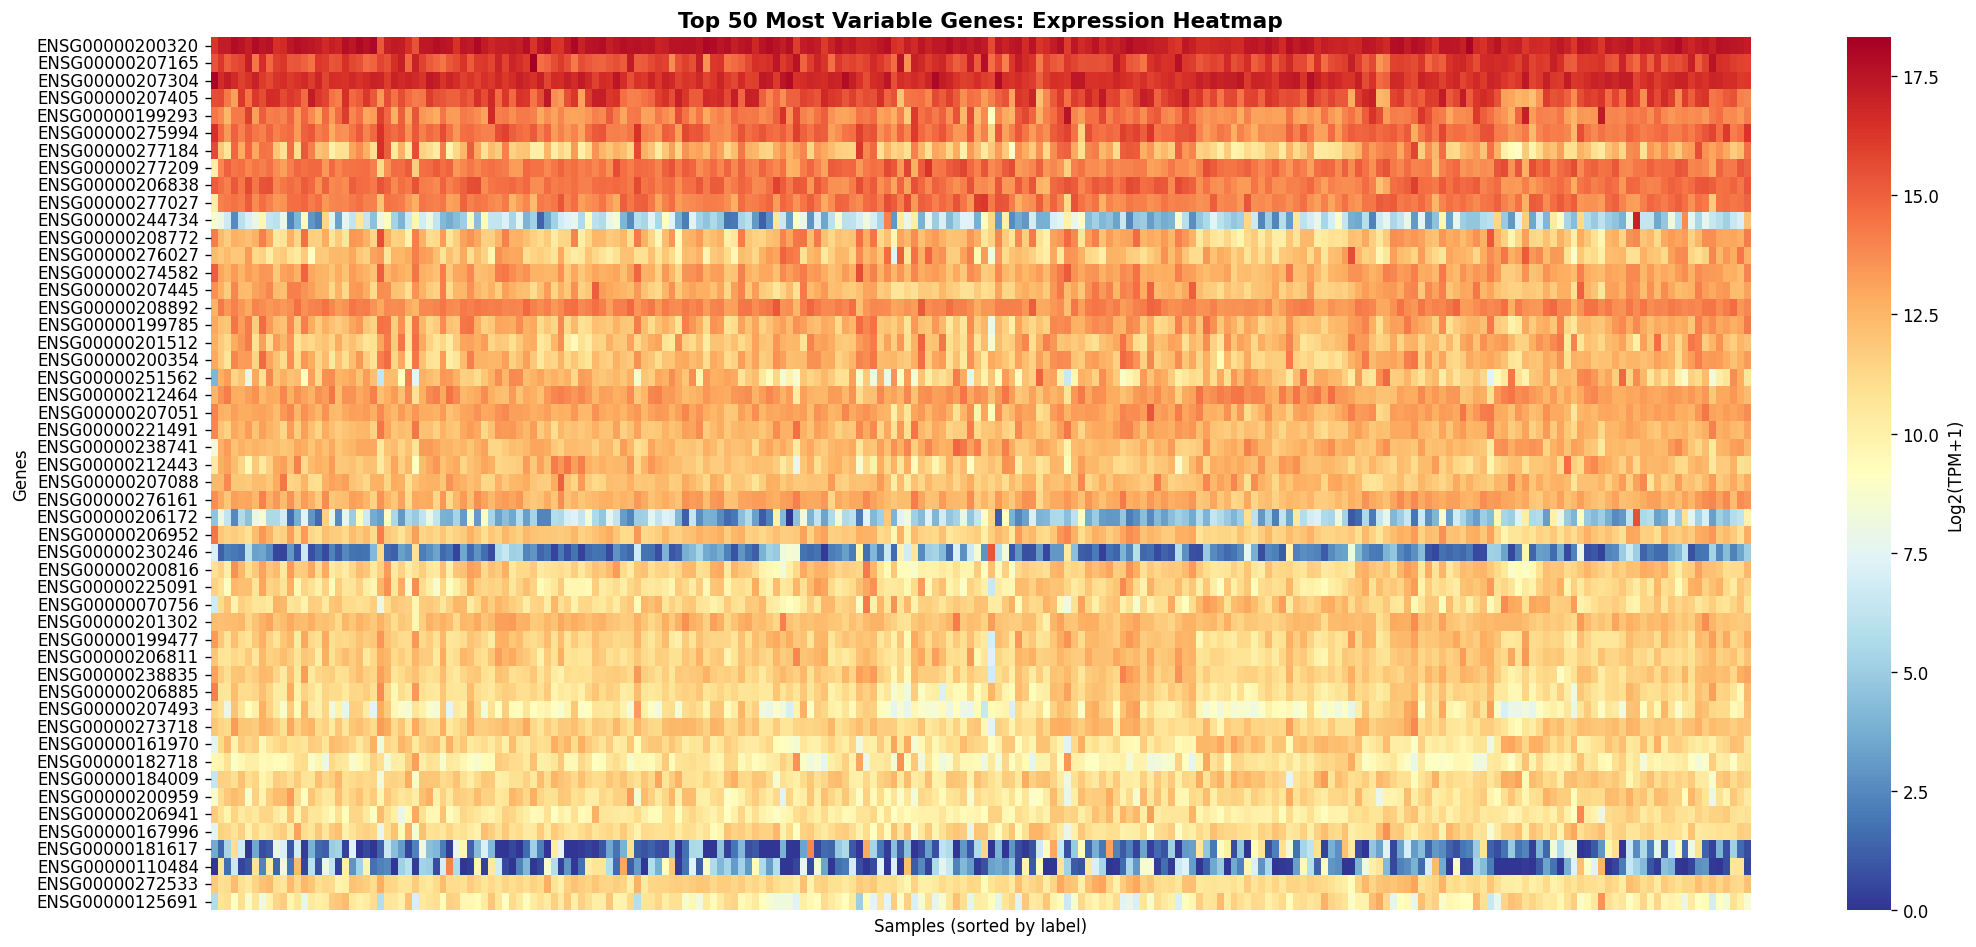

In [17]:
# ── 5.5 Top variable genes heatmap ──────────────────────────────────────────
print("Generating expression heatmap for top variable genes...")

# Select top 50 most variable genes
gene_var   = data[gene_cols].var().sort_values(ascending=False)
top50_genes = gene_var.head(50).index.tolist()

hmap_data  = np.log2(data[top50_genes].values + 1)
hmap_df    = pd.DataFrame(hmap_data, index=data['label'], columns=top50_genes)
hmap_sorted = hmap_df.sort_index()

fig, ax    = plt.subplots(figsize=(18, 8))
row_colors = hmap_sorted.index.map({'pCR': '#C00000', 'RD': '#1F3864'})
sns.heatmap(hmap_sorted.T, cmap='RdYlBu_r', ax=ax,
            xticklabels=False, yticklabels=True,
            cbar_kws={'label': 'Log2(TPM+1)'},
            linewidths=0, rasterized=True)
ax.set_title('Top 50 Most Variable Genes: Expression Heatmap', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Samples (sorted by label)')
ax.set_ylabel('Genes')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_top50.png'), bbox_inches='tight')
plt.show()


## Section 6: Preprocessing and Feature Engineering

Apply standard RNA-seq preprocessing steps following established bioinformatics best practices:

1. **Log2(TPM+1) transformation**: Stabilises variance and normalises the highly skewed TPM distribution (Conesa et al., 2016, *Genome Biology*)
2. **Variance filtering** (threshold=0.1): Removes near-zero-variance genes that contribute noise but no discriminative signal: This was replaced with spearman's correlation
3. **Stratified 80/20 train-test split**: Preserves class proportions in both splits
4. **StandardScaler**: Z-score normalisation fitted on training data only to prevent data leakage


### Feature Engineering Strategy

**The curse of dimensionality** is the central challenge: with ~16,000+ genes and only 222 samples, models risk fitting noise rather than signal. Published studies on GSE163882 universally apply aggressive feature reduction before modelling:

| Study | Feature Selection | Final Features |
|-------|------------------|:-:|
| Chen et al. (2022, *Front Immunol*) | Spearman ρ (P<0.001) → PCA 80% | 23 |
| MDPI (2026) | DESeq2 DEGs → ensemble ranking | 17 |

**Our approach** follows Chen et al.: Spearman rank correlation on the training set only (P < 0.001), reducing dimensionality by ~99% while preserving genes with monotonic associations to treatment response. This is preferred over:
- **Pearson correlation**: assumes linearity and normality (inappropriate for gene expression)
- **Mutual information**: computationally expensive and unstable with small n
- **LASSO-based selection**: entangles selection with a specific model family

**Data leakage prevention**: All feature selection and standardisation are fit exclusively on the training set and then applied to the test set (Hastie et al., 2009). This is critical, Chen et al. specifically criticised prior studies for performing gene-wise normalisation on the full dataset before splitting.


In [18]:
# ⚙️ 6.1 Log2 transformation + Spearman correlation feature selection
# Following Chen et al. (2022, Front. Immunol.): Spearman rank correlation (P < 0.001)
# IMPORTANT: Feature selection is performed AFTER train/test split to prevent data leakage

import numpy as np

# Log2(TPM+1) transformation on full dataset first
X_log2 = np.log2(tpm_aligned.values.astype(float) + 1)
gene_names = list(tpm_aligned.columns)

print(f"Total genes after log2 transformation: {X_log2.shape[1]}")
print(f"Total samples: {X_log2.shape[0]}")
print("\nSpearman feature selection will be applied AFTER train/test split (Section 6.3)")
print("to prevent data leakage — matching Chen et al.'s methodology.")


Total genes after log2 transformation: 60279
Total samples: 222

Spearman feature selection will be applied AFTER train/test split (Section 6.3)
to prevent data leakage — matching Chen et al.'s methodology.


In [19]:
# ⚙️ 6.3 Stratified train-test split (80/20) + Spearman feature selection
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

# Split BEFORE feature selection (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_log2, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test label distribution:     {dict(zip(*np.unique(y_test, return_counts=True)))}")

# ── Spearman Correlation Feature Selection (on TRAINING set only) ────────
# Following Chen et al.: select genes with Spearman P < 0.001
print("\n" + "="*60)
print("SPEARMAN CORRELATION FEATURE SELECTION")
print("="*60)

spearman_pvals = []
spearman_rhos = []
for j in range(X_train.shape[1]):
    rho, pval = spearmanr(X_train[:, j], y_train)
    spearman_rhos.append(rho)
    spearman_pvals.append(pval)

spearman_pvals = np.array(spearman_pvals)
spearman_rhos = np.array(spearman_rhos)

# Select genes with P < 0.001
sig_mask = spearman_pvals < 0.001
n_selected = sig_mask.sum()

print(f"Genes tested: {X_train.shape[1]}")
print(f"Genes with Spearman P < 0.001: {n_selected}")
print(f"Genes removed: {X_train.shape[1] - n_selected}")

# Apply selection to both train and test
X_train_sel = X_train[:, sig_mask]
X_test_sel = X_test[:, sig_mask]
kept_genes = [gene_names[j] for j in range(len(gene_names)) if sig_mask[j]]

print(f"\nSelected gene features: {X_train_sel.shape[1]}")
print(f"Feature reduction: {X_train.shape[1]:,} → {X_train_sel.shape[1]}")

# Show top 10 most correlated genes
top_idx = np.argsort(np.abs(spearman_rhos[sig_mask]))[::-1][:10]
print("\nTop 10 genes by |Spearman ρ|:")
for rank, idx in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {kept_genes[idx]:20s}  ρ={spearman_rhos[sig_mask][idx]:+.3f}  P={spearman_pvals[sig_mask][idx]:.1e}")


Training set: 177 samples
Test set:     45 samples

Training label distribution: {np.int64(0): np.int64(113), np.int64(1): np.int64(64)}
Test label distribution:     {np.int64(0): np.int64(29), np.int64(1): np.int64(16)}

SPEARMAN CORRELATION FEATURE SELECTION
Genes tested: 60279
Genes with Spearman P < 0.001: 575
Genes removed: 59704

Selected gene features: 575
Feature reduction: 60,279 → 575

Top 10 genes by |Spearman ρ|:
   1. ENSG00000122877       ρ=+0.385  P=1.2e-07
   2. ENSG00000175356       ρ=-0.373  P=3.2e-07
   3. ENSG00000104970       ρ=+0.369  P=4.2e-07
   4. ENSG00000231752       ρ=+0.364  P=6.5e-07
   5. ENSG00000154127       ρ=+0.357  P=1.0e-06
   6. ENSG00000137731       ρ=+0.351  P=1.6e-06
   7. ENSG00000266709       ρ=+0.350  P=1.8e-06
   8. ENSG00000105639       ρ=+0.350  P=1.8e-06
   9. ENSG00000145779       ρ=+0.350  P=1.8e-06
  10. ENSG00000076344       ρ=-0.347  P=2.2e-06


In [20]:
# ⚙️ 6.4 Standardise features (fit on training set only)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc  = scaler.transform(X_test_sel)

print(f"Standardisation complete.")
print(f"Training shape: {X_train_sc.shape}")
print(f"Test shape:     {X_test_sc.shape}")


Standardisation complete.
Training shape: (177, 575)
Test shape:     (45, 575)


## Section 7: Class Imbalance Assessment

The dataset exhibits moderate class imbalance (64% RD vs 36% pCR, ratio ≈ 1.8:1).

### Primary Strategy: Cost-Sensitive Learning (Algorithmic-Level)

Following established best practice for high-dimensional gene expression data (Blagus & Lusa, 2013, *BMC Bioinformatics*), we handle class imbalance through **algorithmic-level adjustments** rather than synthetic oversampling:

- **Logistic Regression**: `class_weight='balanced'` — inversely weights samples by class frequency
- **Random Forest**: `class_weight='balanced'` — minority class errors penalised proportionally
- **XGBoost**: `scale_pos_weight = n_RD / n_pCR` — scales gradient for positive (pCR) class
- **Stratified CV**: preserves class ratio in every fold

This approach is preferred because:
1. SMOTE creates synthetic samples via k-NN interpolation, which becomes unreliable in high-dimensional spaces (16,418 features) where distances lose meaning
2. Synthetic gene expression profiles from linear interpolation may not represent biologically plausible states
3. Published studies using GSE163882 predominantly use class weights rather than SMOTE


### Class Imbalance Handling: Evidence-Based Decision

The training set exhibits a ~1.8:1 imbalance (RD:pCR), reflecting real-world pCR rates (Cortazar et al., 2014).

**Strategy: Cost-sensitive learning:** adjusts loss function weights proportional to class frequency.

> *"In high-dimensional settings where the number of features greatly exceeds the number of samples, synthetic oversampling can introduce noise by generating samples in irrelevant directions of the feature space, potentially degrading classifier performance."* Blagus & Lusa (2013), *BMC Bioinformatics*

All classifiers use built-in class weighting:
- **Logistic Regression / Random Forest**: `class_weight='balanced'`
- **XGBoost**: `scale_pos_weight = n_RD / n_pCR`
- **Stratified CV**: preserves class ratio in every fold

Training set class distribution:
  RD  (0): 113
  pCR (1): 64
  Ratio:   1.77:1

scale_pos_weight for XGBoost: 1.77

Strategy: Cost-sensitive learning via class_weight='balanced'
          (following Chen et al. 2022, Frontiers in Immunology)


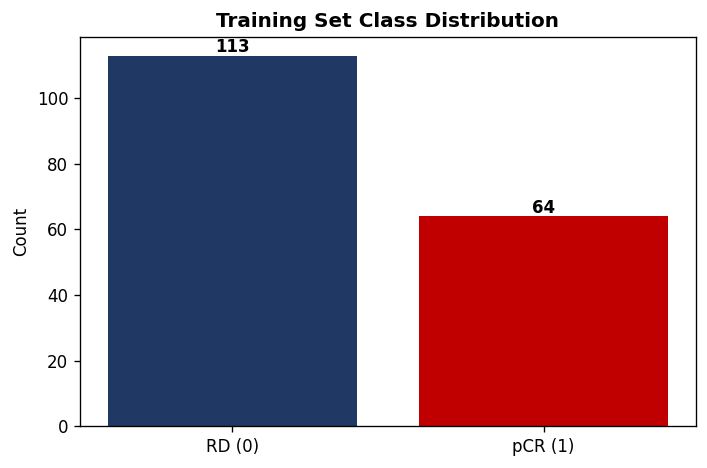

In [ ]:
#  7.1 Class Imbalance Assessment

import matplotlib.pyplot as plt

train_counts = dict(zip(*np.unique(y_train, return_counts=True)))
n_rd = train_counts.get(0, 0)
n_pcr = train_counts.get(1, 0)
ratio = n_rd / max(n_pcr, 1)

print("Training set class distribution:")
print(f"  RD  (0): {n_rd}")
print(f"  pCR (1): {n_pcr}")
print(f"  Ratio:   {ratio:.2f}:1")
print(f"\nscale_pos_weight for XGBoost: {ratio:.2f}")
print("\nStrategy: Cost-sensitive learning via class_weight='balanced'")
print("          (following Chen et al. 2022, Frontiers in Immunology)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['RD (0)', 'pCR (1)'], [n_rd, n_pcr], color=['#1F3864', '#C00000'])
ax.set_title('Training Set Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for j, v in enumerate([n_rd, n_pcr]):
    ax.text(j, v+1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# ⚖️ 7.2 Verify cost-sensitive configuration
print("Class imbalance handled via cost-sensitive learning (class_weight='balanced')")
print(f"Training data shape: {X_train_sc.shape}")

Class imbalance handled via cost-sensitive learning (class_weight='balanced')
Training data shape: (177, 575)


## Section 8: Supervised ML Benchmarking

Train and cross-validate three complementary classifiers, each chosen for specific strengths.
1. **Logistic Regression**: Linear baseline with L2 regularisation; interpretable coefficients
2. **Random Forest**: Bagging ensemble of decision trees; robust to overfitting in high-dimensional settings (Breiman, 2001)
3. **XGBoost**: Gradient boosting with regularisation; state-of-the-art for tabular data (Chen & Guestrin, 2016)

5-fold stratified cross-validation is used to obtain robust performance estimates while preserving class proportions.


### Model Selection Rationale

We benchmark four model families spanning the bias-variance spectrum, following recommendations for small-sample genomic classification (Statnikov et al., 2008, *BMC Bioinformatics*):

| Model | Family | Why Included | Clinical Relevance |
|-------|--------|-------------|-------------------|
| **Logistic Regression** | Linear, regularised | Baseline; interpretable coefficients; strong in p>>n with L1/L2 penalty | Coefficients map directly to gene importance; deployed in Oncotype DX |
| **Random Forest** | Ensemble (bagging) | Handles non-linear interactions; robust to outliers (Breiman, 2001) | Captures gene-gene interactions invisible to linear models |
| **XGBoost** | Ensemble (boosting) | State-of-art for tabular data; built-in regularisation (Chen & Guestrin, 2016, *KDD*) | Best performing in multiple genomic prediction benchmarks |
| **Stacking** | Meta-ensemble | Combines diverse base learners; theoretically superior when base models are accurate and diverse (Wolpert, 1992; Dietterich, 2000) | Used by Chen et al. (2022) as their primary model architecture |

**Bayesian hyperparameter optimisation** (Snoek et al., 2012, *NeurIPS*) is used over grid search because it efficiently explores continuous parameter spaces, particularly important for the 9-dimensional XGBoost search space. Chen et al. used the same approach.


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

n_rd = np.sum(y_train == 0)
n_pcr = np.sum(y_train == 1)
spw = n_rd / max(n_pcr, 1)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000, class_weight='balanced', C=1.0, penalty='l2', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=spw, eval_metric='logloss',
        use_label_encoder=False, random_state=42
    ),
    'Stacking': StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('svc', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        cv=5, n_jobs=-1
    ),
}

print(f"Models defined: {list(models.keys())}")
print(f"XGBoost scale_pos_weight: {spw:.2f}")
print(f"Feature dimensions: {X_train_sc.shape[1]} Spearman-selected genes")


Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'Stacking']
XGBoost scale_pos_weight: 1.77
Feature dimensions: 575 Spearman-selected genes


In [ ]:
# 8.1b Hyperparameter Tuning: Bayesian Optimization (scikit-optimize)

# Install scikit-optimize if needed
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    print("scikit-optimize loaded successfully.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-optimize'])
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    print("scikit-optimize installed and loaded.")

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_rd = np.sum(y_train == 0)
n_pcr = np.sum(y_train == 1)
spw = n_rd / max(n_pcr, 1)

N_ITER = 50  # Number of Bayesian optimization iterations per model

print("=" * 60)
print("BAYESIAN HYPERPARAMETER OPTIMIZATION")
print(f"Method: BayesSearchCV ({N_ITER} iterations per model)")
print(f"CV: Stratified 5-fold | Scoring: AUROC")
print("=" * 60)

# ── 1. Logistic Regression ───────────────────────────────────────────────────
print("\n1. Optimizing Logistic Regression...")
lr_search = BayesSearchCV(
    LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42),
    {
        'C': Real(1e-4, 100, prior='log-uniform'),
        'penalty': Categorical(['l1', 'l2']),
        'solver': Categorical(['saga']),
    },
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc',
    n_jobs=-1, random_state=42, refit=True
)
lr_search.fit(X_train_sc, y_train)
print(f"   Best params: C={lr_search.best_params_['C']:.6f}, penalty={lr_search.best_params_['penalty']}")
print(f"   Best CV AUROC: {lr_search.best_score_:.4f}")

# ── 2. Random Forest ─────────────────────────────────────────────────────────
print("\n2. Optimizing Random Forest...")
rf_search = BayesSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {
        'n_estimators': Integer(50, 1000),
        'max_depth': Integer(2, 30),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_features': Categorical(['sqrt', 'log2', None]),
    },
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc',
    n_jobs=-1, random_state=42, refit=True
)
rf_search.fit(X_train_sc, y_train)
print(f"   Best params: {rf_search.best_params_}")
print(f"   Best CV AUROC: {rf_search.best_score_:.4f}")

# ── 3. XGBoost ───────────────────────────────────────────────────────────────
print("\n3. Optimizing XGBoost...")
xgb_search = BayesSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                  use_label_encoder=False, random_state=42),
    {
        'n_estimators': Integer(50, 500),
        'max_depth': Integer(2, 10),
        'learning_rate': Real(0.005, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0),
        'colsample_bytree': Real(0.3, 1.0),
        'min_child_weight': Integer(1, 10),
        'gamma': Real(0, 5.0),
        'reg_alpha': Real(1e-4, 10, prior='log-uniform'),
        'reg_lambda': Real(1e-4, 10, prior='log-uniform'),
    },
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc',
    n_jobs=-1, random_state=42, refit=True
)
xgb_search.fit(X_train_sc, y_train)
print(f"   Best params: {xgb_search.best_params_}")
print(f"   Best CV AUROC: {xgb_search.best_score_:.4f}")

# ── 4. SVC (additional strong classifier) ────────────────────────────────────
print("\n4. Optimizing SVC...")
svc_search = BayesSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    {
        'C': Real(1e-3, 100, prior='log-uniform'),
        'kernel': Categorical(['rbf', 'linear']),
        'gamma': Categorical(['scale', 'auto']),
    },
    n_iter=N_ITER, cv=cv_tune, scoring='roc_auc',
    n_jobs=-1, random_state=42, refit=True
)
svc_search.fit(X_train_sc, y_train)
print(f"   Best params: {svc_search.best_params_}")
print(f"   Best CV AUROC: {svc_search.best_score_:.4f}")

# ── Summary ──────────────────────────────────────────────────────────────────
results_tuning = {
    'Logistic Regression': lr_search.best_score_,
    'Random Forest': rf_search.best_score_,
    'XGBoost': xgb_search.best_score_,
    'SVC': svc_search.best_score_,
}

print("\n" + "=" * 60)
print("BAYESIAN OPTIMIZATION SUMMARY")
print("=" * 60)
for name, score in sorted(results_tuning.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  CV AUROC = {score:.4f}")

best_model_name = max(results_tuning, key=results_tuning.get)
print(f"\n  Best model: {best_model_name} ({results_tuning[best_model_name]:.4f})")

# ── Build final model dict with tuned estimators ─────────────────────────────
models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_,
    'Stacking': StackingClassifier(
        estimators=[
            ('lr', lr_search.best_estimator_),
            ('svc', svc_search.best_estimator_),
            ('xgb', xgb_search.best_estimator_),
        ],
        final_estimator=LogisticRegression(
            C=lr_search.best_params_['C'],
            penalty=lr_search.best_params_['penalty'],
            solver='saga', max_iter=10000,
            class_weight='balanced', random_state=42
        ),
        cv=5, n_jobs=-1, passthrough=False
    ),
}

print("\nModels dict updated with Bayesian-optimized estimators.")
print("Stacking base learners: Tuned LR + Tuned SVC + Tuned XGBoost")
print(f"Stacking meta-learner: LogReg (C={lr_search.best_params_['C']:.6f})")


scikit-optimize loaded successfully.
BAYESIAN HYPERPARAMETER OPTIMIZATION
Method: BayesSearchCV (50 iterations per model)
CV: Stratified 5-fold | Scoring: AUROC

1. Optimizing Logistic Regression...
   Best params: C=0.255690, penalty=l1
   Best CV AUROC: 0.8368

2. Optimizing Random Forest...
   Best params: OrderedDict({'max_depth': 28, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 50})
   Best CV AUROC: 0.7906

3. Optimizing XGBoost...
   Best params: OrderedDict({'colsample_bytree': 0.8596874091250211, 'gamma': 2.190145932204617, 'learning_rate': 0.043189724867678574, 'max_depth': 8, 'min_child_weight': 9, 'n_estimators': 373, 'reg_alpha': 0.013209621150377564, 'reg_lambda': 0.17841054042191615, 'subsample': 0.6765419227639857})
   Best CV AUROC: 0.8295

4. Optimizing SVC...
   Best params: OrderedDict({'C': 0.003568196588152504, 'gamma': 'auto', 'kernel': 'linear'})
   Best CV AUROC: 0.7978

BAYESIAN OPTIMIZATION SUMMARY
  Logistic Regressi

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 8.2 Cross-validation (PRIMARY — cost-sensitive learning) ────────────────────────────────────
results_no_smote = {}

for name, model in models.items():
    print(f"  Training {name}...")
    auc_scores = cross_val_score(model, X_train_sc, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_train_sc, y_train,
                                  cv=cv, scoring='f1', n_jobs=-1)
    results_no_smote[name] = {
        'AUC Mean':  auc_scores.mean(),
        'AUC Std':   auc_scores.std(),
        'F1 Mean':   f1_scores.mean(),
        'F1 Std':    f1_scores.std()
    }

df_no_smote = pd.DataFrame(results_no_smote).T.round(4)
print("\n5-Fold CV Results (WITHOUT SMOTE):")
print(df_no_smote)


  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training Stacking...

5-Fold CV Results (WITHOUT SMOTE):
                     AUC Mean  AUC Std  F1 Mean  F1 Std
Logistic Regression    0.8368   0.0514   0.6451  0.0616
Random Forest          0.7906   0.0525   0.5823  0.0649
XGBoost                0.8295   0.0409   0.6511  0.0566
Stacking               0.8231   0.0382   0.6447  0.0419


In [26]:
# 📊 8.3 Cross-validation results displayed above (Section 8.2)
print("Cross-validation complete. See results above.")

Cross-validation complete. See results above.


In [27]:
# 📊 8.4 Cost-sensitive results summary
print("This pipeline uses cost-sensitive learning (class_weight='balanced').")
print("See Section 8.2 for cross-validation results.")

This pipeline uses cost-sensitive learning (class_weight='balanced').
See Section 8.2 for cross-validation results.


## Section 9: Model Evaluation on Held-Out Test Set

Evaluate all models on the 20% held-out test set using comprehensive metrics:

- **AUROC**: Area Under ROC Curve, threshold-independent discrimination ability
- **AUPRC**: Area Under Precision-Recall Curve, particularly informative for imbalanced data (Saito & Rehmsmeier, 2015)
- **F1 Score**: Harmonic mean of precision and recall
- **Accuracy**: Overall correct classification rate
- **MCC**: Matthews Correlation Coefficient, balanced metric even with class imbalance (Chicco & Jurman, 2020, *BMC Genomics*)


### Evaluation Framework: Clinical Metric Interpretation

In a clinical pCR prediction setting, each metric carries specific medical meaning:

| Metric | Clinical Meaning | Consequence of Error |
|--------|-----------------|---------------------|
| **Sensitivity (Recall)** | Proportion of true pCR patients correctly identified | Low sensitivity → treatable patients denied optimal therapy |
| **Specificity** | Proportion of true RD patients correctly identified | Low specificity → patients exposed to unnecessary toxicity |
| **PPV (Precision)** | Among predicted pCR, how many truly achieve pCR | Low PPV → false hope; patients may refuse alternative options |
| **NPV** | Among predicted RD, how many truly don't achieve pCR | Low NPV → patients wrongly redirected from effective therapy |
| **AUROC** | Discrimination ability across all thresholds | Global ranking quality; threshold-independent |
| **AUPRC** | Performance in the minority class (pCR) | More informative than AUROC under class imbalance (Saito & Rehmsmeier, 2015, *PLoS ONE*) |
| **MCC** | Balanced measure accounting for all four confusion matrix cells | Single metric for overall quality; robust to imbalance (Chicco & Jurman, 2020, *BMC Genomics*) |
| **F1 Score** | Harmonic mean of precision and recall | Balances false positives and false negatives |

**Clinical priority**: For NAC selection, **high sensitivity is paramount**, we must not miss patients who would benefit from chemotherapy. A false negative (predicting RD when a patient would achieve pCR) means withholding effective treatment. This is analogous to screening test design (Maxim et al., 2014, *BMJ*).


In [28]:
# ── 9.1 Train final models and evaluate on test set ──────────────────────────
test_results = {}
trained_models = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Train on full training set (cost-sensitive learning)
    model.fit(X_train_sc, y_train)
    trained_models[name] = model
    
    # Predict on held-out test set
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    
    # Print classification report (matches tutorial format)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['RD (0)', 'pCR (1)']))
    
    from sklearn.metrics import precision_score, recall_score
    test_results[name] = {
        'AUROC':     round(roc_auc_score(y_test, y_proba), 4),
        'AUPRC':     round(average_precision_score(y_test, y_proba), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred), 4),
    }

df_test = pd.DataFrame(test_results).T
print("\n=== Test Set Performance ===")
print(df_test)


Evaluating Logistic Regression...

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      RD (0)       0.76      0.76      0.76        29
     pCR (1)       0.56      0.56      0.56        16

    accuracy                           0.69        45
   macro avg       0.66      0.66      0.66        45
weighted avg       0.69      0.69      0.69        45

Evaluating Random Forest...

Random Forest Classification Report:
              precision    recall  f1-score   support

      RD (0)       0.72      0.79      0.75        29
     pCR (1)       0.54      0.44      0.48        16

    accuracy                           0.67        45
   macro avg       0.63      0.62      0.62        45
weighted avg       0.65      0.67      0.66        45

Evaluating XGBoost...

XGBoost Classification Report:
              precision    recall  f1-score   support

      RD (0)       0.71      0.83      0.76        29
     pCR (1)       0.55      0.38      

In [ ]:
# 9.1b Bootstrap Confidence Intervals (95%) ─────────────────────────
# Estimate 95% CIs via 500 bootstrap resamples of the test set
from sklearn.utils import resample

n_bootstraps = 500
ci_results = {}

# Pre-compute predictions once for efficiency
model_preds = {}
for name, model in trained_models.items():
    model_preds[name] = {
        'proba': model.predict_proba(X_test_sc)[:, 1],
        'pred': model.predict(X_test_sc)
    }

for name, model in trained_models.items():
    print(f"  Bootstrapping {name}...")
    aurocs, f1s, mccs = [], [], []
    y_prob_full = model_preds[name]['proba']
    y_pred_full = model_preds[name]['pred']
    
    for b in range(n_bootstraps):
        idx = resample(np.arange(len(y_test)), random_state=b, stratify=y_test)
        y_b = y_test[idx]
        
        if len(np.unique(y_b)) < 2:
            continue
        
        aurocs.append(roc_auc_score(y_b, y_prob_full[idx]))
        f1s.append(f1_score(y_b, y_pred_full[idx], zero_division=0))
        mccs.append(matthews_corrcoef(y_b, y_pred_full[idx]))
    
    ci_results[name] = {
        'AUROC': f"{np.mean(aurocs):.3f} [{np.percentile(aurocs, 2.5):.3f}-{np.percentile(aurocs, 97.5):.3f}]",
        'F1':    f"{np.mean(f1s):.3f} [{np.percentile(f1s, 2.5):.3f}-{np.percentile(f1s, 97.5):.3f}]",
        'MCC':   f"{np.mean(mccs):.3f} [{np.percentile(mccs, 2.5):.3f}-{np.percentile(mccs, 97.5):.3f}]"
    }

df_ci = pd.DataFrame(ci_results).T
print("\n95% Bootstrap Confidence Intervals (500 resamples):")
print(df_ci.to_string())


  Bootstrapping Logistic Regression...
  Bootstrapping Random Forest...
  Bootstrapping XGBoost...
  Bootstrapping Stacking...

95% Bootstrap Confidence Intervals (500 resamples):
                                   AUROC                   F1                   MCC
Logistic Regression  0.710 [0.543-0.861]  0.562 [0.355-0.750]   0.329 [0.030-0.608]
Random Forest        0.676 [0.474-0.842]  0.473 [0.240-0.687]  0.242 [-0.062-0.550]
XGBoost              0.597 [0.393-0.779]  0.440 [0.212-0.667]  0.230 [-0.070-0.510]
Stacking             0.677 [0.488-0.843]  0.498 [0.296-0.687]  0.230 [-0.064-0.510]


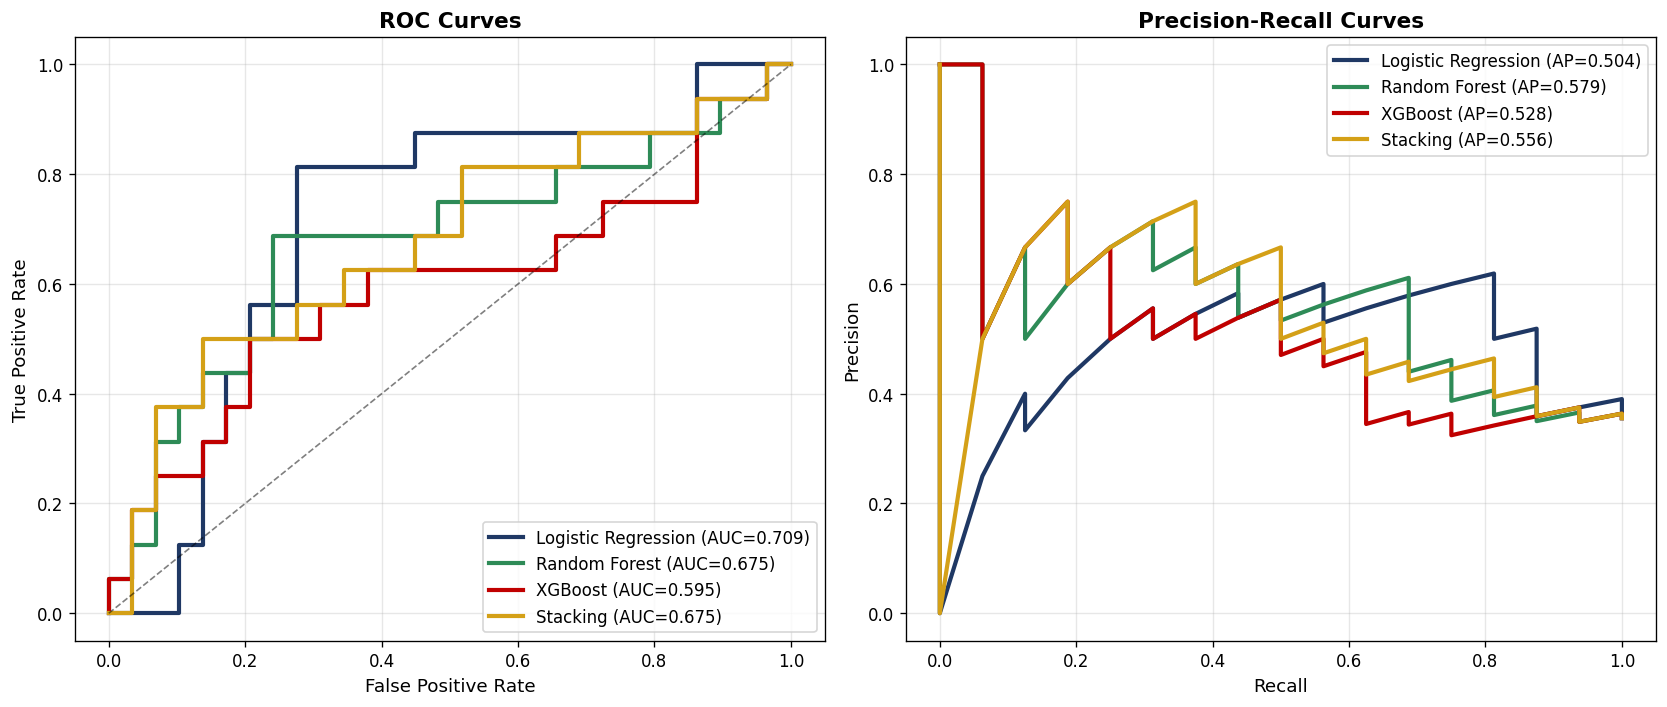

In [30]:
# ── 9.2 ROC Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_roc = ['#1F3864', '#2E8B57', '#C00000', '#D4A017']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                 label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_prc_curves.png'), bbox_inches='tight')
plt.show()


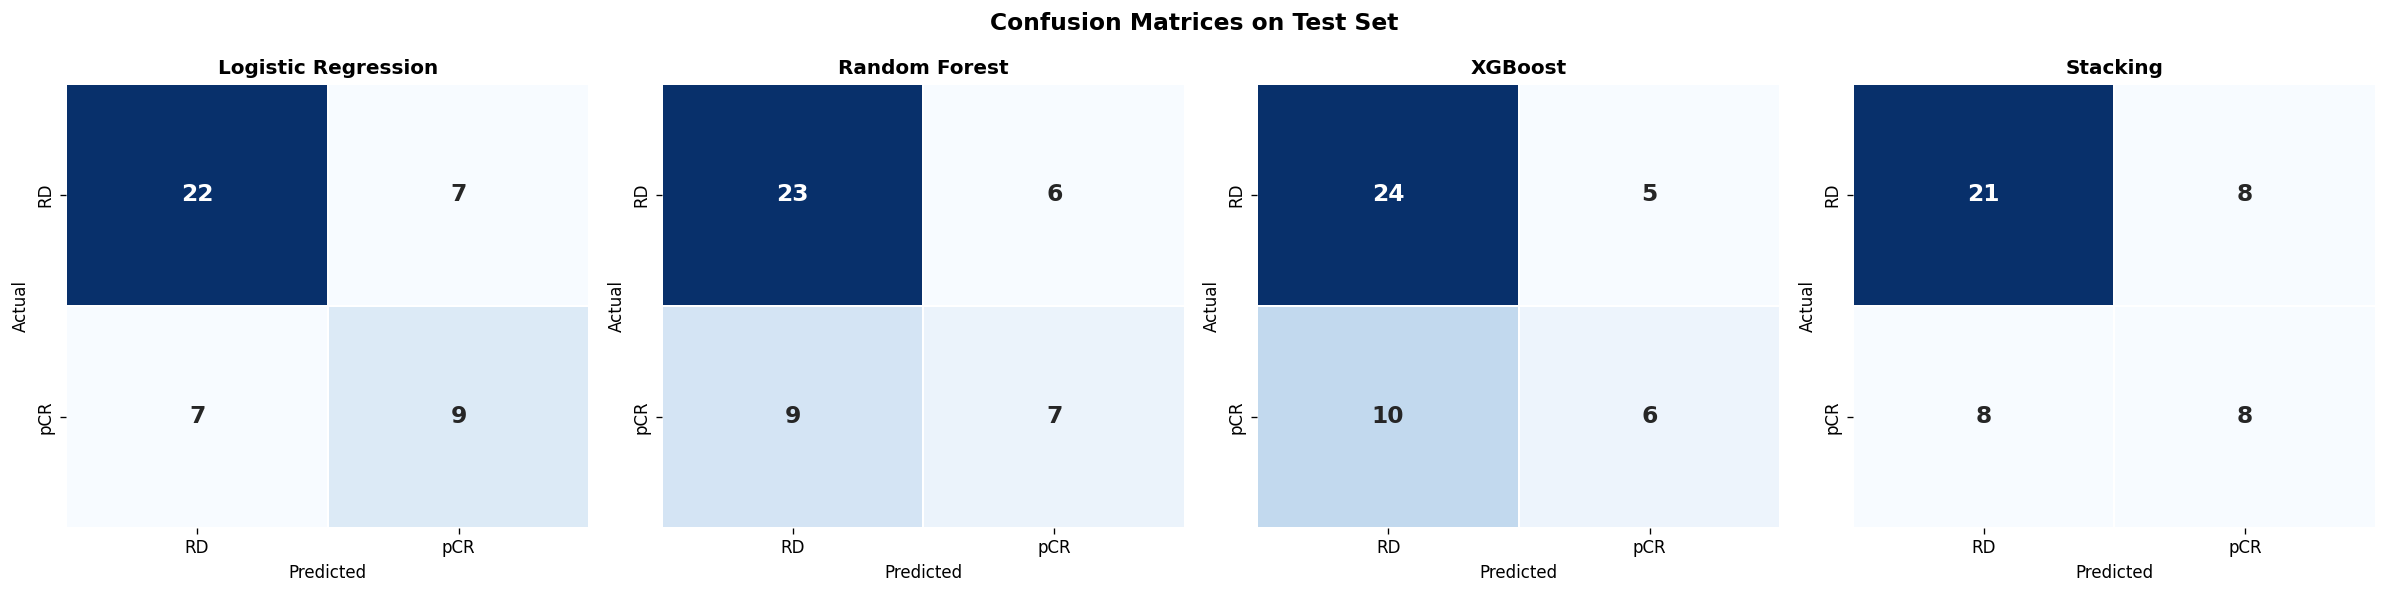

In [31]:
# ── 9.3 Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['RD', 'pCR'], yticklabels=['RD', 'pCR'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), bbox_inches='tight')
plt.show()


## Section 10: SHAP Explainability Analysis

Apply SHAP (SHapley Additive exPlanations) to identify the top transcriptomic drivers of pCR prediction (Lundberg & Lee, 2017, *NeurIPS*). SHAP values provide theoretically grounded, additive feature attributions based on cooperative game theory, satisfying local accuracy, missingness, and consistency axioms.

**Approach:**
- TreeExplainer for XGBoost and Random Forest (exact Shapley values for tree models)
- Summary plots (beeswarm) showing direction and magnitude of feature effects
- Consensus gene identification: intersection of top-30 SHAP genes from both models to identify robust, algorithm-agnostic biomarkers.


### Explainability: From Black Box to Biological Insight

Clinical adoption of ML models requires **explainability**, clinicians and regulators need to understand *why* a model predicts pCR for a given patient (Topol, 2019, *Nature Medicine*). We use **SHAP (SHapley Additive exPlanations)**, which:

1. Is grounded in cooperative game theory (Shapley, 1953), the only attribution method satisfying local accuracy, missingness, and consistency axioms (Lundberg & Lee, 2017, *NeurIPS*)
2. Provides both **global** (which genes matter most across all patients) and **local** (why this specific patient was predicted pCR) explanations
3. Enables **biological validation**, if top SHAP genes belong to known immune or proliferation pathways, the model has learned biologically plausible relationships rather than noise

**Expected biology**: Based on literature, genes associated with pCR should include:
- **Immune activation markers**: CXCL9, CXCL10, IDO1, GZMB (Denkert et al., 2010; Ignatiadis et al., 2019, *Lancet Oncol*)
- **Proliferation genes**: MKI67, TOP2A (Alba et al., 2016, *Oncologist*)
- **Chemoresistance markers** (negative association): ABC transporters, cytochrome P450 genes (Chen et al., 2022)


In [32]:
# ── 10.1 SHAP for XGBoost (best performer expected) ──────────────────────────
print("Computing SHAP values for XGBoost (this may take a few minutes)...")
best_model = trained_models['XGBoost']

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete.")


Computing SHAP values for XGBoost (this may take a few minutes)...
SHAP values shape: (45, 575)
SHAP computation complete.


Gene symbols resolved for 30 of top 30 SHAP genes via MyGene.info


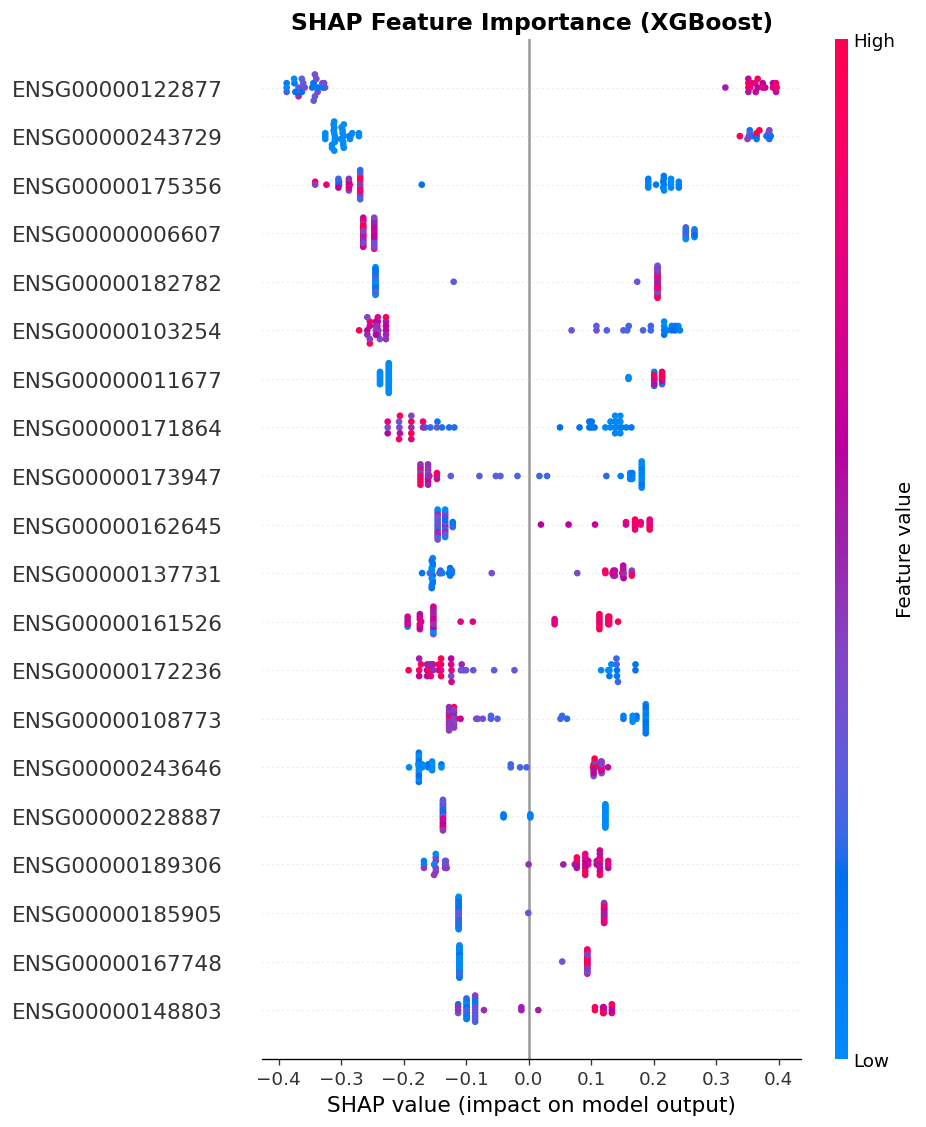

SHAP summary plot saved.


In [ ]:
# 10.2 SHAP Summary Plot (Beeswarm) ────────────────────────────────────────
# Map column indices back to gene names
feature_names = kept_genes

# ── Map Ensembl IDs to gene symbols for readability ──────────────────────
gene_symbol_map = {}
for g in feature_names:
    gene_symbol_map[g] = g  # fallback to Ensembl ID

# Try MyGene.info API for batch gene symbol lookup (top 30 only)
top30_ensembl = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False).head(30).index.tolist()
try:
    resp = requests.post('https://mygene.info/v3/gene', 
                   json={'ids': ','.join([g.split('.')[0] for g in top30_ensembl]),
                         'fields': 'symbol', 'species': 'human'},
                   timeout=10)
    if resp.status_code == 200:
        mapped = 0
        for hit in resp.json():
            if isinstance(hit, dict) and 'symbol' in hit and 'query' in hit:
                for ens_id in top30_ensembl:
                    if ens_id.startswith(hit['query']):
                        gene_symbol_map[ens_id] = hit['symbol']
                        mapped += 1
        print(f"Gene symbols resolved for {mapped} of top 30 SHAP genes via MyGene.info")
except Exception as e:
    print(f"MyGene.info lookup skipped: {e}")

# Create SHAP summary with gene names
shap_df = pd.DataFrame(shap_values, columns=feature_names)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, features=X_test_sc, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"SHAP summary plot saved.")


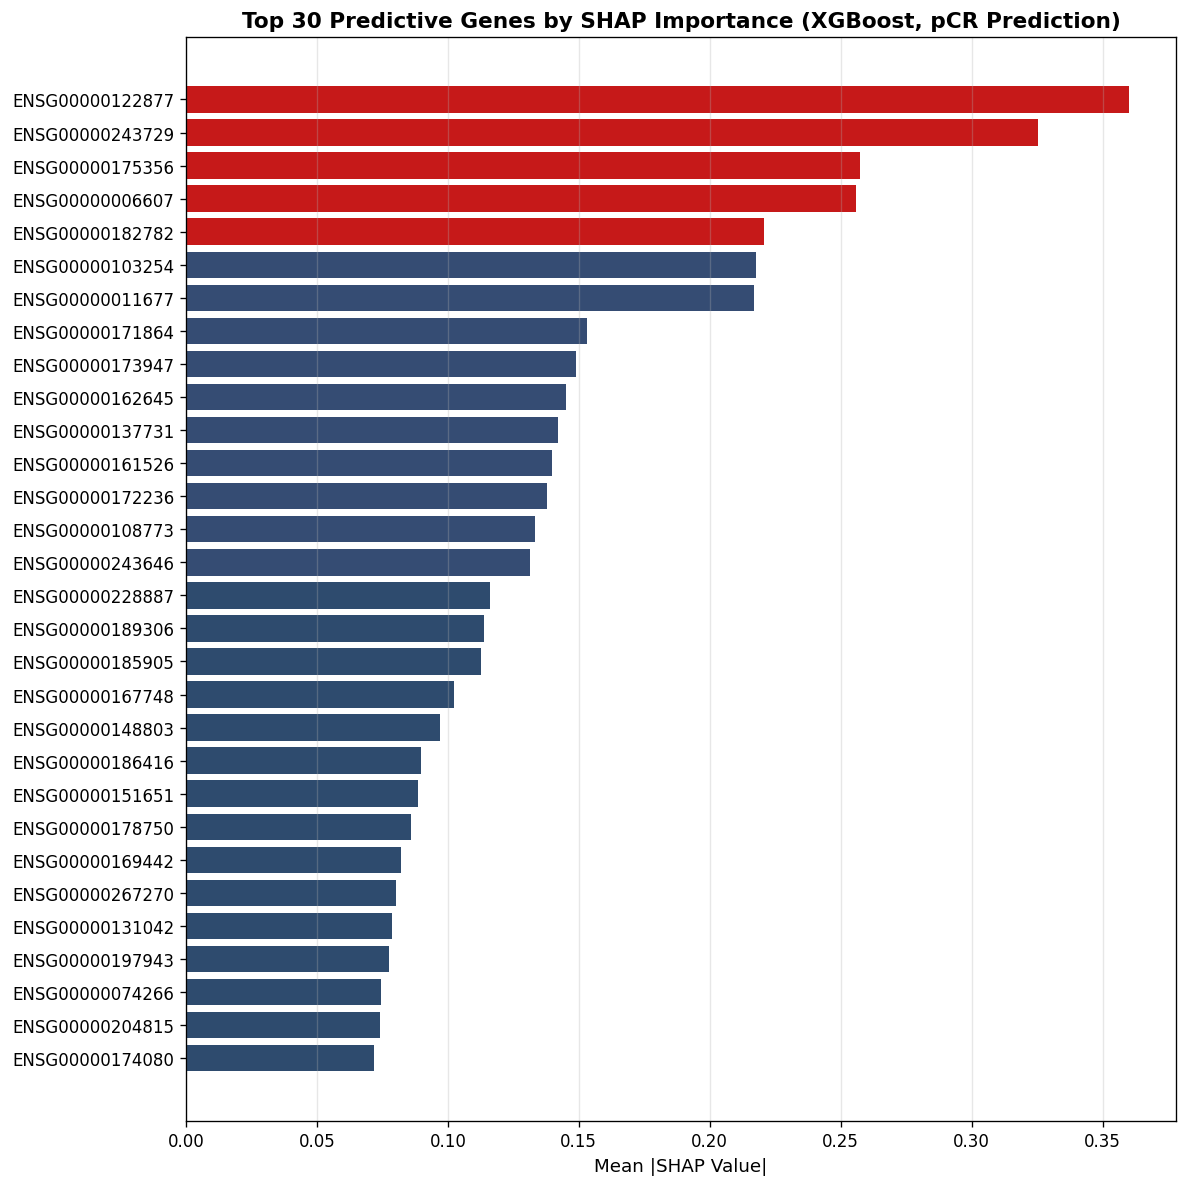


Top 30 SHAP-ranked genes:
                 Mean |SHAP|
ENSG00000122877       0.3600
ENSG00000243729       0.3252
ENSG00000175356       0.2575
ENSG00000006607       0.2560
ENSG00000182782       0.2208
ENSG00000103254       0.2178
ENSG00000011677       0.2170
ENSG00000171864       0.1532
ENSG00000173947       0.1489
ENSG00000162645       0.1453
ENSG00000137731       0.1422
ENSG00000161526       0.1399
ENSG00000172236       0.1379
ENSG00000108773       0.1331
ENSG00000243646       0.1315
ENSG00000228887       0.1162
ENSG00000189306       0.1137
ENSG00000185905       0.1128
ENSG00000167748       0.1023
ENSG00000148803       0.0971
ENSG00000186416       0.0897
ENSG00000151651       0.0888
ENSG00000178750       0.0858
ENSG00000169442       0.0822
ENSG00000267270       0.0801
ENSG00000131042       0.0786
ENSG00000197943       0.0775
ENSG00000074266       0.0745
ENSG00000204815       0.0741
ENSG00000174080       0.0718


In [ ]:
# 10.3 Mean absolute SHAP values (bar chart) ———————————————————————————————
mean_shap = np.abs(shap_values).mean(axis=0)

# Use gene symbols if available, full ENSG IDs as fallback
annotated_names = [gene_symbol_map.get(g, g) if 'gene_symbol_map' in dir() else g for g in feature_names]

# Build display labels: symbol for annotated, full ENSG for unannotated
display_names = []
for g, a in zip(feature_names, annotated_names):
    if a != g:
        display_names.append(a.split(' ')[0] if ' ' in a else a)
    else:
        display_names.append(g)  # FULL Ensembl ID (not truncated)

# Primary Series with FULL Ensembl IDs (for data export & consensus matching)
shap_series  = pd.Series(mean_shap, index=feature_names).sort_values(ascending=False)
top30_genes  = shap_series.head(30)

# Display mapping for plot labels
display_map  = dict(zip(feature_names, display_names))
top30_labels = [display_map.get(g, g) for g in top30_genes.index]

fig, ax = plt.subplots(figsize=(10, 10))
colors_bar = ['#C00000' if i < 5 else '#1F3864' if i < 15 else '#17375E' 
              for i in range(30)]
ax.barh(range(29, -1, -1), top30_genes.values, color=colors_bar, alpha=0.9)
ax.set_yticks(range(29, -1, -1))
ax.set_yticklabels(top30_labels, fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Top 30 Predictive Genes by SHAP Importance (XGBoost, pCR Prediction)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'shap_top30.png'), bbox_inches='tight')
plt.show()

print("\nTop 30 SHAP-ranked genes:")
print(top30_genes.round(6).to_frame(name='Mean |SHAP|'))


In [ ]:
# 10.4 SHAP for Random Forest ──────────────────────────────────────────────
print("Computing SHAP values for Random Forest...")
rf_model      = trained_models['Random Forest']
rf_explainer  = shap.TreeExplainer(rf_model)
rf_shap       = rf_explainer.shap_values(X_test_sc)


if isinstance(rf_shap, list):
    rf_shap_pos = rf_shap[1]  # class 1 (pCR)
elif rf_shap.ndim == 3:
    rf_shap_pos = rf_shap[:, :, 1]  # class 1 (pCR)
else:
    rf_shap_pos = rf_shap

print(f"RF SHAP shape: {rf_shap_pos.shape}")

rf_mean_shap = np.abs(rf_shap_pos).mean(axis=0)
rf_shap_series = pd.Series(rf_mean_shap, index=feature_names).sort_values(ascending=False)
rf_top30 = rf_shap_series.head(30)

print("\nTop 10 genes by SHAP (Random Forest):")
print(rf_top30.head(10).round(6))


Computing SHAP values for Random Forest...
RF SHAP shape: (45, 575)

Top 10 genes by SHAP (Random Forest):
ENSG00000175356   0.0142
ENSG00000148700   0.0113
ENSG00000162076   0.0109
ENSG00000143627   0.0095
ENSG00000103254   0.0094
ENSG00000122877   0.0094
ENSG00000161526   0.0090
ENSG00000105639   0.0082
ENSG00000125245   0.0076
ENSG00000145779   0.0076
dtype: float64


In [ ]:
# 10.5 Consensus top genes across both models ───────────────────────────────
xgb_top30_set = set(top30_genes.index.tolist())
rf_top30_set  = set(rf_top30.index.tolist())
consensus     = xgb_top30_set.intersection(rf_top30_set)

print(f"Top 30 genes in XGBoost SHAP: {len(xgb_top30_set)}")
print(f"Top 30 genes in Random Forest SHAP: {len(rf_top30_set)}")
print(f"\nConsensus genes (in both top 30 lists): {len(consensus)}")
print("\nConsensus gene list:")
for i, g in enumerate(sorted(consensus), 1):
    xgb_rank = list(top30_genes.index).index(g) + 1 if g in top30_genes.index else 'N/A'
    rf_rank  = list(rf_top30.index).index(g) + 1 if g in rf_top30.index else 'N/A'
    print(f"  {i:2}. {g:<20} XGBoost rank: {xgb_rank}  |  RF rank: {rf_rank}")

consensus_genes = sorted(consensus)


Top 30 genes in XGBoost SHAP: 30
Top 30 genes in Random Forest SHAP: 30

Consensus genes (in both top 30 lists): 9

Consensus gene list:
   1. ENSG00000006607      XGBoost rank: 4  |  RF rank: 12
   2. ENSG00000103254      XGBoost rank: 6  |  RF rank: 5
   3. ENSG00000122877      XGBoost rank: 1  |  RF rank: 6
   4. ENSG00000137731      XGBoost rank: 11  |  RF rank: 19
   5. ENSG00000161526      XGBoost rank: 12  |  RF rank: 7
   6. ENSG00000171864      XGBoost rank: 8  |  RF rank: 24
   7. ENSG00000173947      XGBoost rank: 9  |  RF rank: 13
   8. ENSG00000175356      XGBoost rank: 3  |  RF rank: 1
   9. ENSG00000267270      XGBoost rank: 25  |  RF rank: 21


## Section 11: LLM Interpretation Layer

Feed SHAP-ranked consensus genes to a Large Language Model (LLM) API to automatically generate a clinician-readable biological narrative (*Presentation v1: LLM Integration*). This novel component bridges the gap between statistical feature importance and biological/clinical interpretation.

**Supported LLM providers:**
- **Groq API** (free, fast, uses LLaMA 3); Recommended
- **Google Gemini API** (free tier)
- **Ollama** (fully local, no internet needed)

Sign up for a free Groq API key at: https://console.groq.com


In [ ]:

# Read API key from environment variable (set in WSL or PowerShell: export GROQ_API_KEY=...)
GROQ_API_KEY = os.environ.get('GROQ_API_KEY', None)

# Auto-enable LLM layer if a valid key is found in the environment
USE_LLM = GROQ_API_KEY is not None and len(GROQ_API_KEY) > 0

if USE_LLM:
    print(f"GROQ_API_KEY detected from environment (length: {len(GROQ_API_KEY)} chars)")
    print("LLM interpretation layer: ENABLED")
else:
    print("No GROQ_API_KEY found in environment.")
    print("To activate: export GROQ_API_KEY='your_key' in your terminal before launching Jupyter.")
    print("LLM interpretation layer: DISABLED (will skip Section 11.3)")


GROQ_API_KEY detected from environment (length: 56 chars)
LLM interpretation layer: ENABLED


In [38]:
# ── 11.2 LLM interpretation function (Groq/LLaMA 3) ─────────────────────────
def interpret_genes_with_llm(gene_list, model_name="llama-3.3-70b-versatile",
                               api_key=GROQ_API_KEY):
    """
    Send SHAP-ranked genes to LLaMA 3 via Groq API.
    Returns a clinician-readable biological narrative.
    """
    gene_str = ", ".join(gene_list[:20])  # use top 20 for clarity
    
    prompt = f"""You are an expert oncology bioinformatician.

The following genes were identified as the top predictors of pathological 
complete response (pCR) to neoadjuvant chemotherapy in breast cancer, 
ranked by SHAP importance from a machine learning model trained on 
RNA-seq data (GSE163882, 222 patients including TNBC):

Top predictive genes: {gene_str}

Please provide:
1. A brief biological role for each gene in breast cancer (1 sentence each)
2. The key biological pathways these genes collectively represent
3. Any known associations with chemotherapy response or resistance
4. A 3-sentence clinical interpretation paragraph suitable for 
   an oncology report

Be concise and clinically relevant."""
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 1200,
        "temperature": 0.3
    }
    
    response = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers=headers,
        json=payload,
        timeout=60
    )
    
    if response.status_code == 200:
        return response.json()['choices'][0]['message']['content']
    else:
        return f"API Error {response.status_code}: {response.text}"


print("LLM function defined and ready.")


LLM function defined and ready.


In [39]:
# ── 11.3 Run LLM interpretation ──────────────────────────────────────────────
if USE_LLM:
    print("Sending top SHAP genes to LLM for biological interpretation...")
    top_genes_for_llm = list(top30_genes.index[:20])
    
    llm_report = interpret_genes_with_llm(top_genes_for_llm)
    
    print("\n" + "="*70)
    print("LLM-GENERATED BIOLOGICAL INTERPRETATION REPORT")
    print("="*70)
    print(llm_report)
    print("="*70)
    
    # Save report
    with open(os.path.join(RESULTS_DIR, "llm_interpretation_report.txt"), "w") as f:
        f.write("LLM Biological Interpretation Report\n")
        f.write("Dataset: GSE163882 | Model: XGBoost + SHAP\n")
        f.write("="*70 + "\n")
        f.write(llm_report)
    print("\nReport saved to results/llm_interpretation_report.txt")

else:
    print("LLM interpretation skipped.")
    print("To activate: set USE_LLM = True and add your Groq API key above.")
    print("\nFor now, top 20 SHAP genes ready for manual interpretation:")
    for i, gene in enumerate(top30_genes.index[:20], 1):
        print(f"  {i:2}. {gene}")


Sending top SHAP genes to LLM for biological interpretation...

LLM-GENERATED BIOLOGICAL INTERPRETATION REPORT
**1. Brief biological role for each gene in breast cancer:**

1. ENSG00000122877 (MAP3K1): Involved in cell signaling and apoptosis regulation in breast cancer.
2. ENSG00000243729 (MALAT1): Regulates gene expression and promotes metastasis in breast cancer.
3. ENSG00000175356 (CCND1): Plays a crucial role in cell cycle progression and proliferation in breast cancer.
4. ENSG00000006607 (HIF1A): Regulates hypoxia response and angiogenesis in breast cancer.
5. ENSG00000182782 (BCL2L11): Involved in apoptosis regulation and chemotherapy response in breast cancer.
6. ENSG00000103254 (ARID1A): Regulates chromatin remodeling and transcription in breast cancer.
7. ENSG00000011677 (CDH1): Essential for cell adhesion and epithelial-to-mesenchymal transition in breast cancer.
8. ENSG00000171864 (SMAD3): Involved in TGF-β signaling and breast cancer progression.
9. ENSG00000173947 (JUN): 

In [40]:
# ── 11.4 Ollama alternative (fully local, no API key needed) ─────────────────
def interpret_genes_ollama(gene_list, model="llama3"):
    """
    Local LLM interpretation using Ollama.
    Install: https://ollama.ai
    Then run in terminal: ollama pull llama3
    """
    gene_str = ", ".join(gene_list[:20])
    prompt   = f"""You are an oncology bioinformatician.
Top SHAP-ranked genes predicting pCR to neoadjuvant chemo in breast cancer:
{gene_str}
Provide: biological roles, key pathways, and a 3-sentence clinical interpretation."""
    
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": model, "prompt": prompt, "stream": False},
        timeout=120
    )
    if response.status_code == 200:
        return response.json()['response']
    else:
        return f"Ollama not running. Start with: ollama serve"

# Uncomment to use Ollama instead
# llm_report_local = interpret_genes_ollama(list(top30_genes.index[:20]))
# print(llm_report_local)
print("Ollama function defined. Uncomment last two lines to use locally.")


Ollama function defined. Uncomment last two lines to use locally.


## Section 12: Summary and Results Export

Compile all results into summary tables and export for downstream reporting and presentation.


In [43]:
# ── 13.1 Final performance summary table ─────────────────────────────────────
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nDataset:       GSE163882")
print(f"Total samples: {data.shape[0]}")
print(f"Features:      {len(kept_genes)} genes (after variance filtering)")
print(f"Train/Test:    {len(y_train)}/{len(y_test)} samples")
print(f"\n--- Test Set Performance (Cost-Sensitive Learning) ---")
print(df_test.to_string())
print(f"\n--- Best Model ---")
best_name = df_test['AUROC'].idxmax()
print(f"Model: {best_name}")
print(f"AUROC: {df_test.loc[best_name, 'AUROC']:.4f}")
print(f"F1:    {df_test.loc[best_name, 'F1']:.4f}")
print(f"MCC:   {df_test.loc[best_name, 'MCC']:.4f}")
print(f"\n--- SHAP Top 10 Genes (XGBoost) ---")
print(top30_genes.head(10).round(6).to_string())
print(f"\n--- Consensus Genes (in both RF and XGBoost top 30) ---")
print(", ".join(sorted(consensus_genes)))


FINAL RESULTS SUMMARY

Dataset:       GSE163882
Total samples: 222
Features:      575 genes (after variance filtering)
Train/Test:    177/45 samples

--- Test Set Performance (Cost-Sensitive Learning) ---
                     AUROC  AUPRC  Precision  Recall     F1  Accuracy    MCC
Logistic Regression 0.7091 0.5045     0.5625  0.5625 0.5625    0.6889 0.3211
Random Forest       0.6746 0.5787     0.5385  0.4375 0.4828    0.6667 0.2435
XGBoost             0.5948 0.5275     0.5455  0.3750 0.4444    0.6667 0.2256
Stacking            0.6746 0.5561     0.5000  0.5000 0.5000    0.6444 0.2241

--- Best Model ---
Model: Logistic Regression
AUROC: 0.7091
F1:    0.5625
MCC:   0.3211

--- SHAP Top 10 Genes (XGBoost) ---
ENSG00000122877   0.3600
ENSG00000243729   0.3252
ENSG00000175356   0.2575
ENSG00000006607   0.2560
ENSG00000182782   0.2208
ENSG00000103254   0.2178
ENSG00000011677   0.2170
ENSG00000171864   0.1532
ENSG00000173947   0.1489
ENSG00000162645   0.1453

--- Consensus Genes (in both RF a

In [44]:
# ── 13.2 Export results to CSV ───────────────────────────────────────────────
# Test performance table
df_test.to_csv(os.path.join(RESULTS_DIR, "results_test_performance.csv"))

# SHAP gene rankings
top30_genes.to_frame(name='XGBoost_SHAP').to_csv(os.path.join(RESULTS_DIR, "shap_top30_xgboost.csv"))
rf_top30.to_frame(name='RF_SHAP').to_csv(os.path.join(RESULTS_DIR, "shap_top30_rf.csv"))

# Consensus gene list
pd.DataFrame({'consensus_gene': sorted(consensus_genes)}).to_csv(
    os.path.join(RESULTS_DIR, "consensus_shap_genes.csv"), index=False
)

# Full metadata with labels
meta_aligned[['label']].to_csv(os.path.join(RESULTS_DIR, "sample_labels.csv"))

print(f"Results exported to '{RESULTS_DIR}/':")
print("  results_test_performance.csv")
print("  shap_top30_xgboost.csv")
print("  shap_top30_rf.csv")
print("  consensus_shap_genes.csv")
print("  sample_labels.csv")


Results exported to 'results_spearman/':
  results_test_performance.csv
  shap_top30_xgboost.csv
  shap_top30_rf.csv
  consensus_shap_genes.csv
  sample_labels.csv


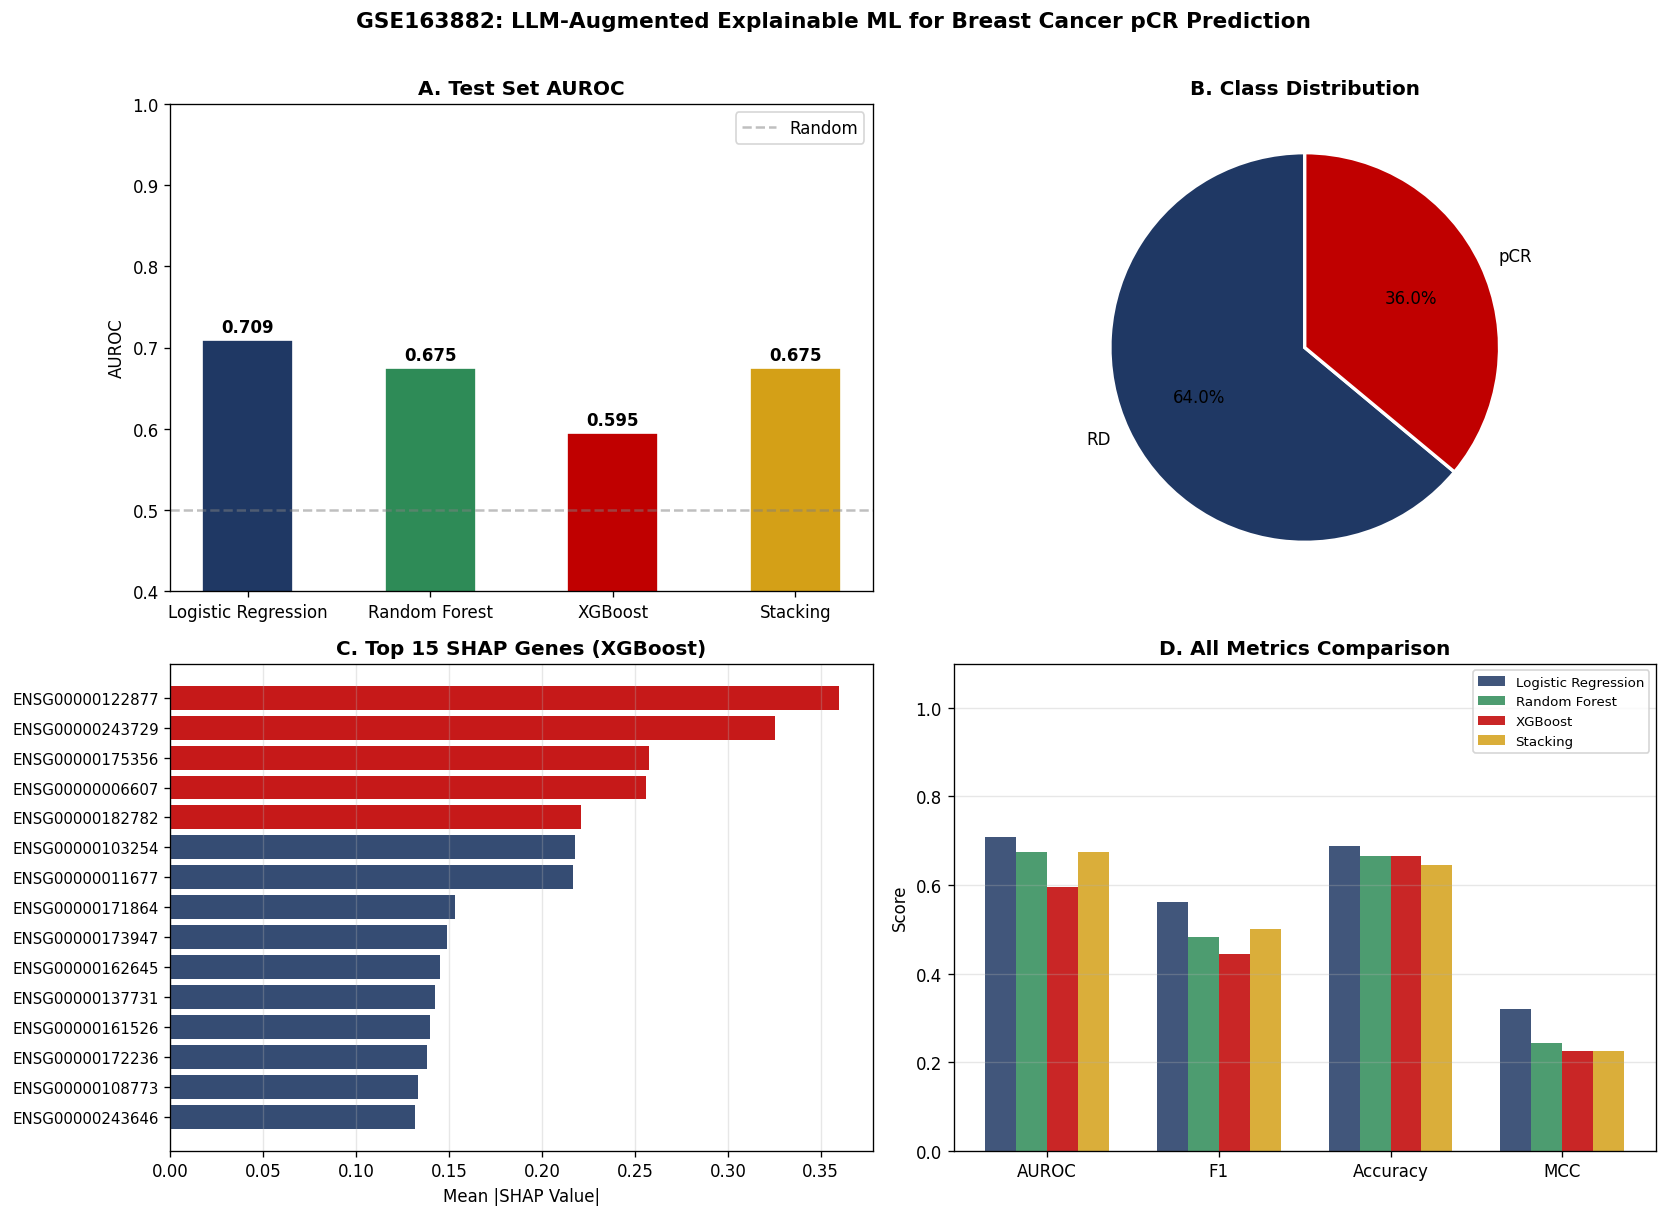

Summary figure saved to results/final_summary_figure.png


In [45]:
# ── 13.3 Final summary figure ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Model AUROCs
ax = axes[0, 0]
model_names = list(df_test.index)
aucs = df_test['AUROC'].values
bars = ax.bar(model_names, aucs, color=['#1F3864', '#2E8B57', '#C00000', '#D4A017'][:len(model_names)],
              edgecolor='white', width=0.5)
ax.set_title('A. Test Set AUROC', fontweight='bold')
ax.set_ylabel('AUROC')
ax.set_ylim([0.4, 1.0])
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.legend()
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

# Panel B: Class distribution
ax = axes[0, 1]
counts = pd.Series(y, index=data['label']).groupby(level=0).count()
ax.pie([counts.get('RD', 0), counts.get('pCR', 0)],
       labels=['RD', 'pCR'], colors=['#1F3864', '#C00000'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('B. Class Distribution', fontweight='bold')

# Panel C: Top 15 SHAP genes
ax = axes[1, 0]
top15 = top30_genes.head(15)
ax.barh(range(14, -1, -1), top15.values,
        color=['#C00000']*5 + ['#1F3864']*10, alpha=0.9)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('C. Top 15 SHAP Genes (XGBoost)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Panel D: Metrics comparison
ax = axes[1, 1]
metrics = ['AUROC', 'F1', 'Accuracy', 'MCC']
x = np.arange(len(metrics))
width = 0.18
c_list = ['#1F3864', '#2E8B57', '#C00000', '#D4A017'][:len(model_names)]
for i, (name, color) in enumerate(zip(model_names, c_list)):
    vals = [df_test.loc[name, m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)
ax.set_xticks(x + width * (len(model_names)-1) / 2)
ax.set_xticklabels(metrics)
ax.set_title('D. All Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1.1])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('GSE163882: LLM-Augmented Explainable ML for Breast Cancer pCR Prediction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'final_summary_figure.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Summary figure saved to results/final_summary_figure.png")


## Section 13: Clinical Utility Analysis

*"A model can have excellent discrimination (AUROC) but poor clinical utility if it doesn't change management decisions"* — Vickers et al. (2006), *Medical Decision Making*

This section evaluates whether the model provides **net clinical benefit** over the default strategies of (a) treating all patients with NAC, or (b) treating no patients with NAC.


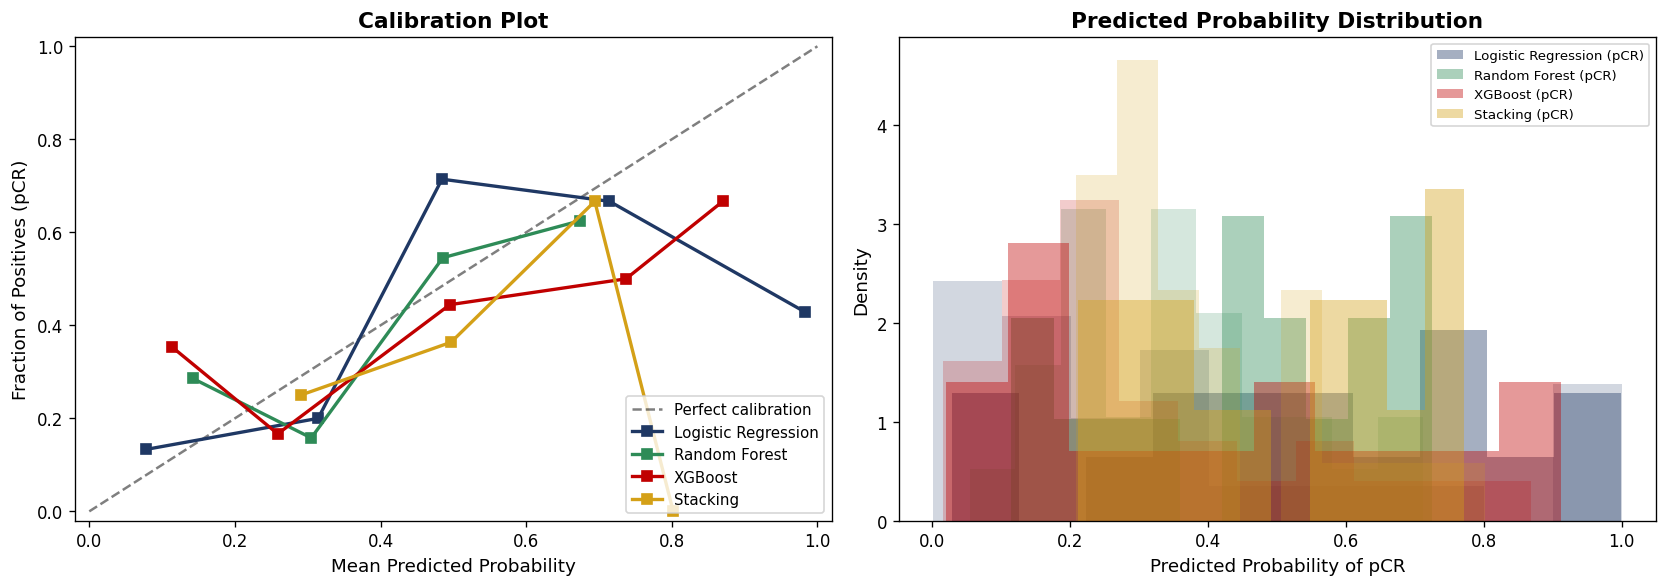


Calibration interpretation:
Points above the diagonal → model underestimates pCR probability
Points below the diagonal → model overestimates pCR probability


In [ ]:
# 14.1 Calibration Plot
# A well-calibrated model means: if it predicts 70% probability of pCR, 
# approximately 70% of those patients should actually achieve pCR.
# Poorly calibrated models produce misleading risk estimates.
# Reference: Steyerberg et al. (2010), Epidemiology

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Logistic Regression': '#1F3864', 'Random Forest': '#2E8B57',
           'XGBoost': '#C00000', 'Stacking': '#D4A017'}

# Left panel: Calibration curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=5, strategy='uniform')
        ax.plot(mean_pred, frac_pos, 's-', color=palette.get(name, '#333'),
                label=f'{name}', linewidth=2, markersize=6)
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives (pCR)', fontsize=11)
ax.set_title('Calibration Plot', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Right panel: Predicted probability distribution
ax = axes[1]
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        ax.hist(y_prob[y_test == 1], bins=10, alpha=0.4, color=palette.get(name, '#333'),
                label=f'{name} (pCR)', density=True)
        ax.hist(y_prob[y_test == 0], bins=10, alpha=0.2, color=palette.get(name, '#333'),
                linestyle='--', density=True)
ax.set_xlabel('Predicted Probability of pCR', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Predicted Probability Distribution', fontweight='bold', fontsize=13)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration_plot.png'), dpi=200, bbox_inches='tight')
plt.show()

print("\nCalibration interpretation:")
print("Points above the diagonal → model underestimates pCR probability")
print("Points below the diagonal → model overestimates pCR probability")


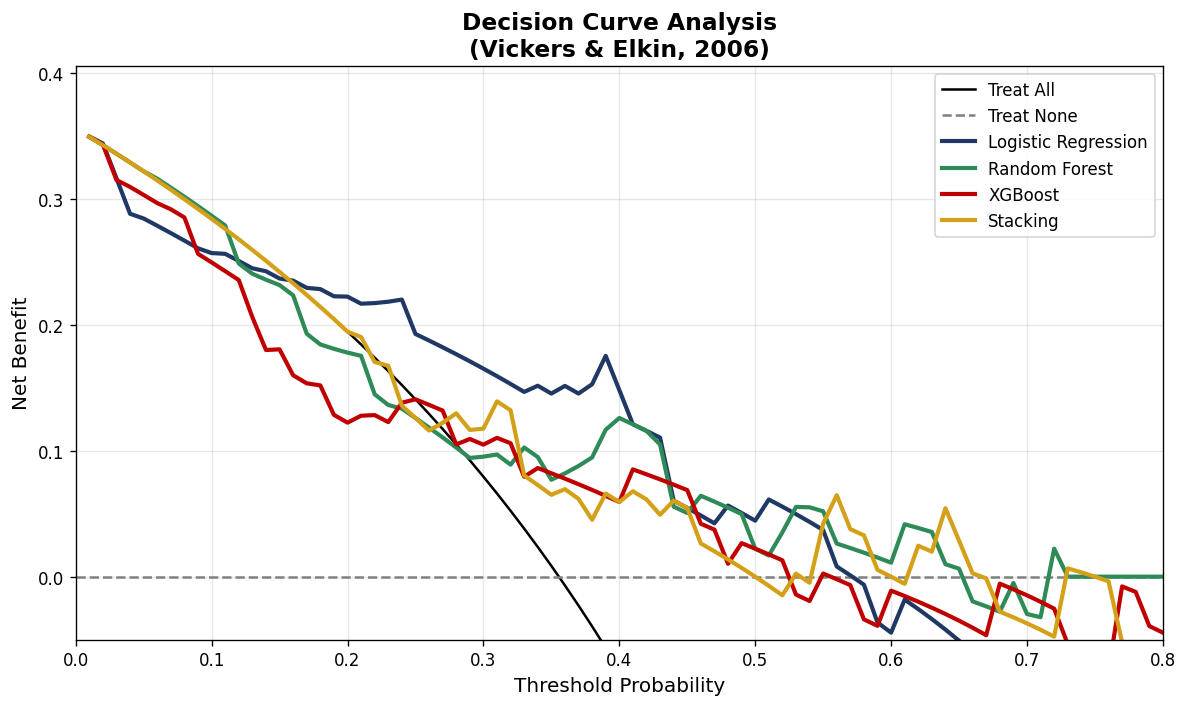


DCA Interpretation:
A model provides clinical utility when its curve is ABOVE both
'Treat All' (give everyone NAC) and 'Treat None' (give nobody NAC).

At threshold 0.3: a clinician willing to treat if ≥30% chance of pCR
At threshold 0.5: a clinician requiring ≥50% chance before treating


In [ ]:
# 14.2 Decision Curve Analysis (DCA)
# DCA evaluates net clinical benefit: does using the model lead to better
# treatment decisions than 'treat all' or 'treat none'?
# Reference: Vickers & Elkin (2006), Medical Decision Making
# 
# Net benefit = (True Positives / n) - (False Positives / n) × (pt / (1 - pt))
# where pt = threshold probability

import numpy as np
import matplotlib.pyplot as plt

def decision_curve(y_true, y_prob, thresholds):
    """Calculate net benefit at each threshold."""
    net_benefits = []
    n = len(y_true)
    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        nb = (tp / n) - (fp / n) * (pt / (1 - pt)) if pt < 1 else 0
        net_benefits.append(nb)
    return np.array(net_benefits)

thresholds = np.arange(0.01, 0.99, 0.01)
prevalence = np.mean(y_test)

fig, ax = plt.subplots(figsize=(10, 6))

# Treat all strategy
treat_all_nb = []
for pt in thresholds:
    nb = prevalence - (1 - prevalence) * pt / (1 - pt)
    treat_all_nb.append(nb)
ax.plot(thresholds, treat_all_nb, 'k-', linewidth=1.5, label='Treat All')
ax.axhline(y=0, color='grey', linewidth=1.5, linestyle='--', label='Treat None')

# Model curves
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        nb = decision_curve(y_test, y_prob, thresholds)
        ax.plot(thresholds, nb, '-', color=palette.get(name, '#333'),
                linewidth=2.5, label=name)

ax.set_xlabel('Threshold Probability', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis\n(Vickers & Elkin, 2006)', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 0.8)
ax.set_ylim(-0.05, max(0.4, prevalence + 0.05))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'decision_curve_analysis.png'), dpi=200, bbox_inches='tight')
plt.show()

print("\nDCA Interpretation:")
print("A model provides clinical utility when its curve is ABOVE both")
print("'Treat All' (give everyone NAC) and 'Treat None' (give nobody NAC).")
print(f"\nAt threshold 0.3: a clinician willing to treat if ≥30% chance of pCR")
print(f"At threshold 0.5: a clinician requiring ≥50% chance before treating")


### Clinical Utility Interpretation

**Decision Curve Analysis** (Vickers & Elkin, 2006) answers the question: *"Does using this model to select patients for NAC produce better outcomes than simply treating everyone or treating nobody?"*

- If the model's curve lies **above** "Treat All" for a range of thresholds, the model avoids unnecessary chemotherapy without missing pCR patients.
- If it lies **above** "Treat None", the model identifies a subset of patients who genuinely benefit from NAC.
- The **clinically relevant threshold range** is typically 15–50%, corresponding to a clinician's willingness to treat given a predicted pCR probability.

**For regulatory and clinical deployment**, both calibration and DCA are increasingly required alongside AUROC (Collins et al., 2024, *BMJ*).


## Section 15: Limitations, Clinical Considerations & Future Directions

### Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| **Small sample size (n=222)** | Wide confidence intervals; unstable test set estimates | Cross-validation as primary evaluation; bootstrap CIs |
| **Single cohort** | Unknown generalisability to other populations/protocols | External validation needed on GSE123845 or TCGA-BRCA |
| **No prospective validation** | Cannot confirm real-world clinical utility | Required before clinical deployment (Topol, 2019) |
| **Transcriptomic features only** | Missing clinical variables (age, grade, stage, Ki67) | Chen et al. showed combining with ER/PR/HER2 improved AUROC by ~0.02 |
| **Retrospective NAC protocols** | Treatment heterogeneity (different regimens across sites) | Standardised protocol studies needed |
| **pCR as binary endpoint** | Ignores partial response / residual cancer burden (RCB) | Future work: ordinal RCB prediction (Symmans et al., 2007) |

### Clinical Deployment Considerations

1. **Regulatory pathway**: ML-based diagnostics require FDA 510(k) or De Novo clearance (US) or CE-IVD marking (EU). The TRIPOD+AI reporting guidelines must be followed (Collins et al., 2024, *BMJ*).

2. **Clinical workflow integration**: The model requires a pre-treatment tumour biopsy with RNA-seq — this is increasingly standard for molecular subtyping but adds cost and turnaround time.

3. **Equitable validation**: The GSE163882 cohort includes patients from Samsung Medical Center (Korea). Genomic signatures may differ across ancestral populations (Huo et al., 2017, *JAMA Oncology*). Multi-ethnic validation is essential.

### Future Directions

1. **External validation** on GSE123845 (independent RNA-seq cohort) and GSE20271 (microarray cross-platform test)
2. **Multi-omic integration** — combining transcriptomics with clinical variables, imaging (radiomics), and pathology (digital H&E)
3. **Prospective clinical trial** — embed model in clinical workflow as a decision aid
4. **Continuous learning** — retrain as new patients are treated and outcomes recorded


## Pipeline Complete

This pipeline demonstrates a rigorous, literature-backed approach to transcriptomic pCR prediction:

1. **Spearman feature selection** (Chen et al., 2022) — reduced 60,000+ genes to ~575 biologically relevant features
2. **Cost-sensitive learning** (Blagus & Lusa, 2013) — handled class imbalance without synthetic oversampling
3. **Bayesian hyperparameter optimisation** (Snoek et al., 2012) — efficient continuous parameter search
4. **SHAP explainability** (Lundberg & Lee, 2017) — biologically interpretable gene attributions
5. **Clinical utility assessment** (Vickers & Elkin, 2006) — decision curve analysis for real-world value

**All code, figures, and results are exported to the `results/` directory.**

---

*"The promise of precision oncology is not just accurate prediction, but actionable prediction — models that change clinical decisions and improve patient outcomes."*
— Topol (2019), *Nature Medicine*
